# Clustering the result of a MCA with K-means

We experiment here with a way of detecting specific profiles in the population using K-means clustering on the results of the MCA.

* [Clustering](https://en.wikipedia.org/wiki/Cluster_analysis) (Wikidata)
* [K-means](https://en.wikipedia.org/wiki/K-means_clustering) (Wikidata)

In [1]:
import numpy as np
import pandas as pd

import sqlite3 as sql

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import seaborn as sns

import networkx as nx
import itertools

import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import fcluster
from scipy.spatial.distance import cdist

import fanalysis.ca as fa 

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from prince import MCA

In [2]:
### Importer un module de fonctions crées ad hoc
##  ATTENTION : le fichier 'sparql_functions.py' doit se trouver 
#   dans un dossier qui se situe dans le chemin ('path') de recherche
#   vu par le présent carnet Jupyter afin que
#   l'importation fonctionne correctement
import sys
from importlib import reload


# Add parent directory to the path
sys.path.insert(0, '..')

### If you want to add the parent-parent directory,
sys.path.insert(0, '../..')


In [3]:

import bivariate_library as bl
import correspondence_analysis_library as cal
import cluster_functions as cf


In [4]:
import warnings
warnings.filterwarnings('ignore')


In [5]:
### Use this command to reload the functions if modified
print(reload(cf))


<module 'cluster_functions' from '/home/ministers/da5_data/cluster_functions.py'>


## Create a dataframe with the data to be analysed

In this notebook, we use the data produced in the [multiple correspondence analysis (MCA) notebook ](da5_MCA.ipynb), which was prepared and exported into this file [this file](da_data/da5-MCA-clusters.csv) after the sparse data was aggregated.




In [6]:
### Import the new qualitative values to be added: occupation and employer class
csv_address='da5-MCA-cluster.csv'
# Explicitly tell pandas which strings to treat as NA (exclude 'NA' from the list)
# By default, pandas treats 'NA', 'N/A', 'NaN', etc. as missing values.
# If you want to override this by specifying a custom list that does NOT include 'NA'.
df_pm = pd.read_csv(csv_address, na_values=['', 'N/A', 'NULL', 'None', 'NaN'])
df_pm = pd.read_csv(csv_address)
df_pm.head()

,person_uri,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,index_right,reg_name,...,activityYear,periodsActivity,pk_person_features,occupation_main,occupation_sec1,occupation_sec2,party_sec1,fk_person,codedSecOccupation,codedSecparty
0,http://www.wikidata.org/entity/Q3839099,Ludovico D'Aragona,1876.0,maschio,Cernusco sul Naviglio,POINT (9.333333 45.516667),http://www.wikidata.org/entity/Q185619,1871-1880,2.0,Lombardia,...,1911.0,1907-1926,355,politico,sindacalista,mancante,Partito Socialista Italiano,355,sindacalista,Sinistra/Centro Sinistra
1,http://www.wikidata.org/entity/Q463243,Carlo Sforza,1872.0,maschio,Montignoso,POINT (10.166667 44.016667),http://www.wikidata.org/entity/Q52236,1871-1880,8.0,Toscana,...,1907.0,1907-1926,461,politico,diplomatico,mancante,Partito Repubblicano Italiano,461,diplomatico,Sinistra/Centro Sinistra
2,http://www.wikidata.org/entity/Q3771001,Giuseppe Micheli,1874.0,maschio,Parma,POINT (10.328 44.801472),http://www.wikidata.org/entity/Q2683,1871-1880,7.0,Emilia-Romagna,...,1909.0,1907-1926,331,politico,mancante,mancante,Partito Popolare Italiano,331,mancante,Centro
3,http://www.wikidata.org/entity/Q1242,Luigi Einaudi,1874.0,maschio,Carrù,POINT (7.883333 44.483333),http://www.wikidata.org/entity/Q19372,1871-1880,0.0,Piemonte,...,1909.0,1907-1926,41,politico,avvocato,giornalista,Partito Liberale Italiano,41,avvocato,Destra/Centro Destra
4,http://www.wikidata.org/entity/Q3839683,Luigi Gasparotto,1873.0,maschio,Sacile,POINT (12.50274 45.95412),http://www.wikidata.org/entity/Q53190,1871-1880,5.0,Friuli-Venezia Giulia,...,1908.0,1907-1926,358,politico,avvocato,mancante,Partito Democratico del Lavoro,358,avvocato,Sinistra/Centro Sinistra


In [7]:
print(df_pm.columns.to_list())

['person_uri', 'labelPer', 'birthYear', 'gender', 'labelPlace', 'geometry', 'uriPlace', 'periods', 'index_right', 'reg_name', 'reg_istat_code_num', 'reg_istat_code', 'coded_Region', 'activityYear', 'periodsActivity', 'pk_person_features', 'occupation_main', 'occupation_sec1', 'occupation_sec2', 'party_sec1', 'fk_person', 'codedSecOccupation', 'codedSecparty']


In [8]:
df_pm.columns = [
    'person_uri', 
    'labelPer', 
    'birthYear', 
    'gender', 
    'labelPlace', 
    'geometry', 
    'uriPlace', 
    'periods', 
    'index_right', 
    'REGION',             # Ex 'reg_name'
    'reg_istat_num', 
    'reg_istat_code',
    'coded_Region',
    'activityYear',
    'periodsActivity',
    'pk_person_features', 
    'occupation_main', 
    'occup_sec1', 
    'occup_sec2', 
    'party',              # Ex 'party_main' 
    'fk_person',
    'codedSecOccupation',
    'codedSecparty']

In [9]:
### Inspect the dataframe and 
# notably if there are missing values
df_pm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 561 entries, 0 to 560
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   person_uri          561 non-null    object 
 1   labelPer            559 non-null    object 
 2   birthYear           561 non-null    float64
 3   gender              561 non-null    object 
 4   labelPlace          561 non-null    object 
 5   geometry            561 non-null    object 
 6   uriPlace            561 non-null    object 
 7   periods             561 non-null    object 
 8   index_right         561 non-null    float64
 9   REGION              561 non-null    object 
 10  reg_istat_num       561 non-null    float64
 11  reg_istat_code      561 non-null    float64
 12  coded_Region        561 non-null    object 
 13  activityYear        561 non-null    float64
 14  periodsActivity     561 non-null    object 
 15  pk_person_features  561 non-null    int64  
 16  occupati

In [10]:
### change display options for jupyter notebooks
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
# Reset to default settings if needed later
# pd.reset_option('display.max_columns')

## Multiple factor analysis (MCA)

We only consider for MCA the coded features of persons, transformed into qualitative categories 

We don't use the periods for defining profiles, our research question is about inspecting the correlation between profiles and periods, and identify specific profiles for specific periods

In [11]:
### Define the variables that will be used for analysing the population profiles
df_actives = df_pm[['gender', 'coded_Region', 'codedSecOccupation', 'codedSecparty']].copy(deep=True)
print(df_actives.columns)
df_actives.head(2)

Index(['gender', 'coded_Region', 'codedSecOccupation', 'codedSecparty'], dtype='object')


,gender,coded_Region,codedSecOccupation,codedSecparty
0,maschio,Nord,sindacalista,Sinistra/Centro Sinistra
1,maschio,Centro,diplomatico,Sinistra/Centro Sinistra


#### Process in two steps

First fit, then transform.

The mca variable will be used to project illustrative variables, in our case periods of activity

In [12]:
### MCA with benzecri correction: whole intertia in 5 axis
# Equivalent to fit_transform but in to steps
mca = MCA(n_components=70, n_iter=10, correction='benzecri',random_state=42)
mca.fit(df_actives)

,n_components,70
,n_iter,10
,copy,True
,check_input,True
,random_state,42
,engine,'sklearn'
,one_hot,True
,one_hot_prefix_sep,'__'
,one_hot_columns_to_drop,None
,correction,'benzecri'


In [13]:
### Benzecri correction and approximation allows to summarize 
# the most relevant aspects of the variance in five axes (in this case)
mca.eigenvalues_summary.head(32)

,eigenvalue,% of variance,% of variance (cumulative)
component,,,
0,0.022,36.10%,36.10%
1,0.016,26.06%,62.16%
2,0.012,19.17%,81.33%
3,0.006,9.33%,90.67%
4,0.004,6.34%,97.01%
5,0.002,2.99%,100.00%
6,0.000,0.00%,100.00%
7,0.000,0.00%,100.00%
8,0.000,0.00%,100.00%


#### Test without Benzecri correction

In [14]:
### Save scree_plot without benzecri correction
# 58 dimensions/axis are needed to express the inertia/variation
# Image saved manually
mca_t = MCA(n_components=70, n_iter=10,random_state=42)
mca_t.fit(df_actives)
# mca_t.scree_plot()

,n_components,70
,n_iter,10
,copy,True
,check_input,True
,random_state,42
,engine,'sklearn'
,one_hot,True
,one_hot_prefix_sep,'__'
,one_hot_columns_to_drop,None
,correction,None


In [15]:
### Benzecri correction and approximation allows to summarize 
# the most relevant aspects of the variance in five axes (in this case)
mca_t.eigenvalues_summary.head(32)

,eigenvalue,% of variance,% of variance (cumulative)
component,,,
0,0.362,5.79%,5.79%
1,0.345,5.52%,11.31%
2,0.331,5.30%,16.61%
3,0.307,4.91%,21.52%
4,0.297,4.75%,26.27%
5,0.282,4.51%,30.79%
6,0.250,4.00%,34.79%
7,0.250,4.00%,38.79%
8,0.250,4.00%,42.79%


### Keep 10 components

In [16]:
### MCA with benzecri correction: whole intertia in 10 axis
# Equivalent to fit_transform but in to steps
mca = MCA(n_components=10, n_iter=10, correction='benzecri',random_state=42)
mca.fit(df_actives)


,n_components,10
,n_iter,10
,copy,True
,check_input,True
,random_state,42
,engine,'sklearn'
,one_hot,True
,one_hot_prefix_sep,'__'
,one_hot_columns_to_drop,None
,correction,'benzecri'


In [17]:
### Benzecri correction and approximation allows to summarize 
# the most relevant aspects of the variance in five axes (in this case)
mca.eigenvalues_summary.head(30)

,eigenvalue,% of variance,% of variance (cumulative)
component,,,
0,0.022,36.17%,36.17%
1,0.016,26.10%,62.28%
2,0.012,19.20%,81.48%
3,0.006,9.35%,90.83%
4,0.004,6.35%,97.17%
5,0.002,2.83%,100.00%
6,0.000,0.00%,100.00%
7,0.000,0.00%,100.00%
8,0.000,0.00%,100.00%


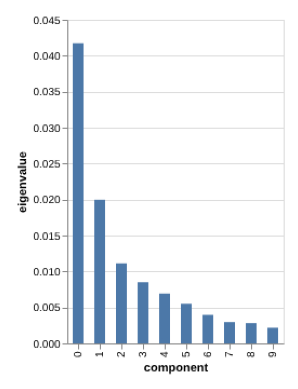

In [18]:
mca.scree_plot()
### saved as png, not visible on github


### Show image scree plot (visible on github)

img_address='doc_images/mca_prince_scree_plot.png'
# Read the image
img = mpimg.imread(img_address)

# Display the image
plt.imshow(img)
plt.axis('off')  # Hide axes
plt.show()


In [19]:
### categories coordinates, i.e. columns in the complete disjoint table
print(len(mca.column_coordinates(df_actives)))
dfcc = mca.column_coordinates(df_actives)
dfcc.head()

29


,0,1,2,3,4,5,6,7,8,9
gender__femmina,0.347012,-0.639140,-0.698531,-0.765256,1.693248,-0.895249,1.428065e-12,-1.143738e-13,-7.580742e-15,1.283175e-14
gender__maschio,-0.040784,0.075118,0.082098,0.089940,-0.199007,0.105219,-1.677807e-13,1.339553e-14,1.000935e-15,-1.498801e-15
coded_Region__Centro,-0.227797,1.162033,-0.443497,-0.644115,-0.259224,-0.350804,-7.373685e-13,8.493076e-14,-5.949234e-15,7.598089e-15
coded_Region__Nord,0.247396,-0.381544,-0.449109,0.590731,-0.065666,-0.025775,2.304285e-13,-3.823331e-14,2.914335e-15,-4.905798e-15
coded_Region__Sud,-0.195766,-0.279781,0.970311,-0.395566,0.281342,0.289131,1.946845e-13,-5.641321e-15,3.417405e-16,1.706968e-15


In [20]:
### individual coordinates (rows)
# The same result as using the method 'fit_transform'
print(len(mca.row_coordinates(df_actives)))
dfrc = mca.row_coordinates(df_actives)
dfrc.head()

561


,0,1,2,3,4,5,6,7,8,9
0,-0.386804,0.129781,0.067008,1.123505,1.003600,1.024100,1.195317,-0.971840,-0.538426,-0.297676
1,-0.299877,1.066600,-0.067761,-0.052153,-0.079009,-0.420307,-1.048647,1.581477,0.716160,-0.061669
2,-0.423890,-0.410308,-0.038532,0.377465,-0.225275,-0.419763,0.082631,-0.062126,0.030245,-0.000871
3,0.081528,-0.824032,-0.317842,-0.234726,-0.297774,0.484738,-0.188685,-0.060381,-0.095628,0.104758
4,-0.179567,-0.141754,-0.044903,0.293555,0.149330,0.433472,-0.188685,-0.060381,-0.095628,0.104758


In [21]:
### Equivalent to mca.row_coordinates(df_actives)
X_mca=mca.transform(df_actives)

In [22]:
X_mca.head(2)

,0,1,2,3,4,5,6,7,8,9
0,-0.386804,0.129781,0.067008,1.123505,1.003600,1.024100,1.195317,-0.971840,-0.538426,-0.297676
1,-0.299877,1.066600,-0.067761,-0.052153,-0.079009,-0.420307,-1.048647,1.581477,0.716160,-0.061669


#### Create directly a mapping with the individuals

In [23]:
### Fit MCA and use factor scores as input to KMeans
# The Benzecri correction reduces the number of components
mca_1 = MCA(n_components=10, n_iter=10, correction='benzecri',random_state=42)
X_mca_1 = mca_1.fit_transform(df_actives)
X_mca_1.head()

,0,1,2,3,4,5,6,7,8,9
0,-0.386804,0.129781,0.067008,1.123505,1.003600,1.024100,1.195317,-0.971840,-0.538426,-0.297676
1,-0.299877,1.066600,-0.067761,-0.052153,-0.079009,-0.420307,-1.048647,1.581477,0.716160,-0.061669
2,-0.423890,-0.410308,-0.038532,0.377465,-0.225275,-0.419763,0.082631,-0.062126,0.030245,-0.000871
3,0.081528,-0.824032,-0.317842,-0.234726,-0.297774,0.484738,-0.188685,-0.060381,-0.095628,0.104758
4,-0.179567,-0.141754,-0.044903,0.293555,0.149330,0.433472,-0.188685,-0.060381,-0.095628,0.104758


### Plot categories, first two axis

In [24]:
ax1=mca.eigenvalues_summary.iloc[0, 1]
ax2=mca.eigenvalues_summary.iloc[1, 1]

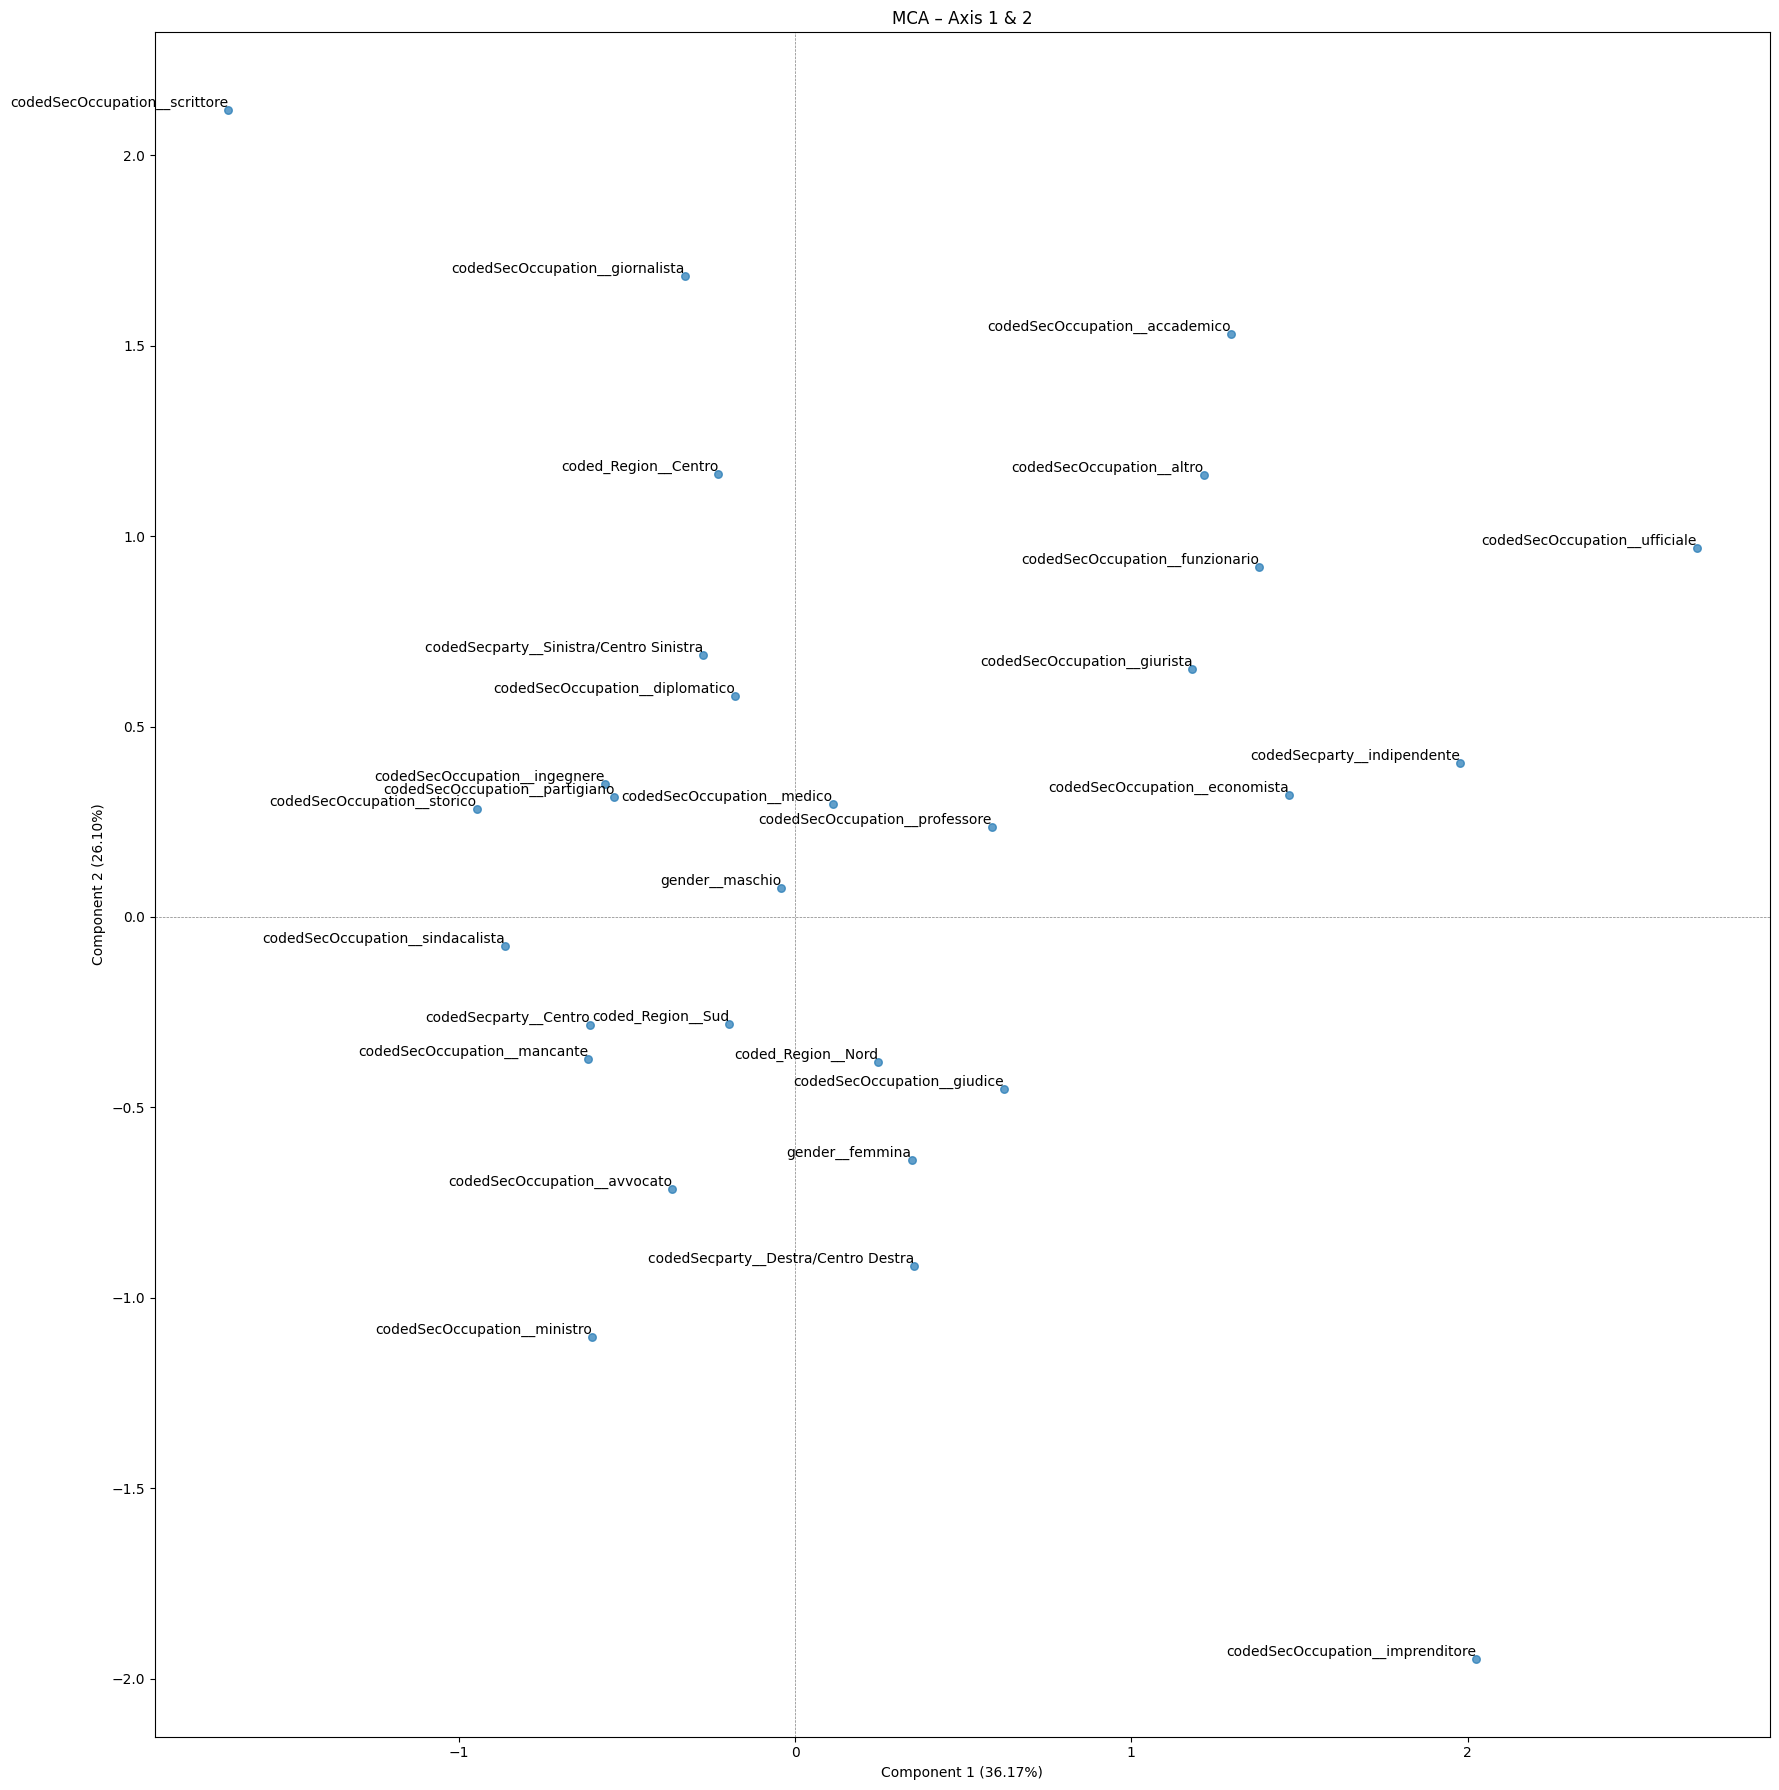

In [25]:

fig, ax = plt.subplots(figsize=(18, 18))

ax.scatter(dfcc[0], dfcc[1], s=30, alpha=0.7)

# Label each point with its index
for label, x, y in zip(dfcc.index, dfcc[0], dfcc[1]):
    ax.annotate(label, (x, y), fontsize=10, ha='right', va='bottom')

ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.5, linestyle='--')
ax.set_xlabel(f"Component 1 ({ax1})")
ax.set_ylabel(f"Component 2 ({ax2})")
ax.set_title("MCA – Axis 1 & 2")

plt.tight_layout()
plt.show()

### Calculate position of illustrative variable 'per_activ'

We don't use the periods for defining profiles, our research question is about inspecting the correlation between profiles and periods, and identify specific profiles for specific periods

In [26]:
df_illustrative = df_pm[['periodsActivity']].copy(deep=True)
df_illustrative.head(2)

,periodsActivity
0,1907-1926
1,1907-1926


In [27]:
df_per_activ=pd.DataFrame(df_pm.groupby('periodsActivity').size())
# df_per_activ.index=df_per_activ.index.map(lambda x: f'per_activ__{x}')
df_per_activ.columns=['number']
df_per_activ

,number
periodsActivity,
1907-1926,41
1927-1946,70
1947-1966,152
1967-1986,166
1987-2006,99
2007-2026,33


In [28]:
### This script situates the illustrative variable 'per_activ'
# at the mean position in the geometric space using the coordinates 
# of all the individuals

row_coords = mca.row_coordinates(df_actives)

# 3. Select the single illustrative variable column
illus_var = df_illustrative['periodsActivity'] # Replace with actual column name

# 4. Calculate position for each category in that variable
supp_positions = {}

for category in illus_var.dropna().unique():
    # Find indices of individuals who have this category
    mask = illus_var == category
    
    # Calculate the barycenter (mean) of their row coordinates
    # This is the position of the supplementary category
    centroid = row_coords[mask].mean(axis=0)
    
    supp_positions[category] = centroid.values

# 5. Convert to DataFrame for easy use/plotting
df_per_activ_pos = pd.DataFrame(
    supp_positions, 
    index=[i for i in range(row_coords.shape[1])]
).T  # Transpose so rows are categories, columns are dimensions

df_per_activ_pos

,0,1,2,3,4,5,6,7,8,9
1907-1926,-0.117335,-0.013653,0.079794,0.076869,-0.176766,0.054095,-0.039336,-0.061098,-0.028843,-0.022510
1927-1946,-0.214402,-0.080179,0.099953,0.170114,-0.116891,-0.100343,-0.056824,0.068896,-0.024407,0.075278
1947-1966,-0.204631,0.134170,0.082380,0.112261,-0.071219,-0.007116,-0.009542,-0.035940,0.004762,0.066145
1967-1986,0.202661,-0.005607,0.002310,0.025655,0.054068,0.082834,0.008593,-0.011075,0.011107,-0.094270
1987-2006,0.212097,-0.088712,-0.173206,-0.275877,0.057747,0.022429,0.060842,0.059527,0.007539,0.014185
2007-2026,-0.112622,-0.136618,-0.182610,-0.274850,0.350389,-0.305549,-0.012389,-0.027559,-0.012815,-0.004726


In [29]:
### We add the label and the number of individuals to the mean position
df_per_activ=df_per_activ.join(df_per_activ_pos)


In [30]:
df_per_activ.head(2)

,number,0,1,2,3,4,5,6,7,8,9
periodsActivity,,,,,,,,,,,
1907-1926,41,-0.117335,-0.013653,0.079794,0.076869,-0.176766,0.054095,-0.039336,-0.061098,-0.028843,-0.022510
1927-1946,70,-0.214402,-0.080179,0.099953,0.170114,-0.116891,-0.100343,-0.056824,0.068896,-0.024407,0.075278


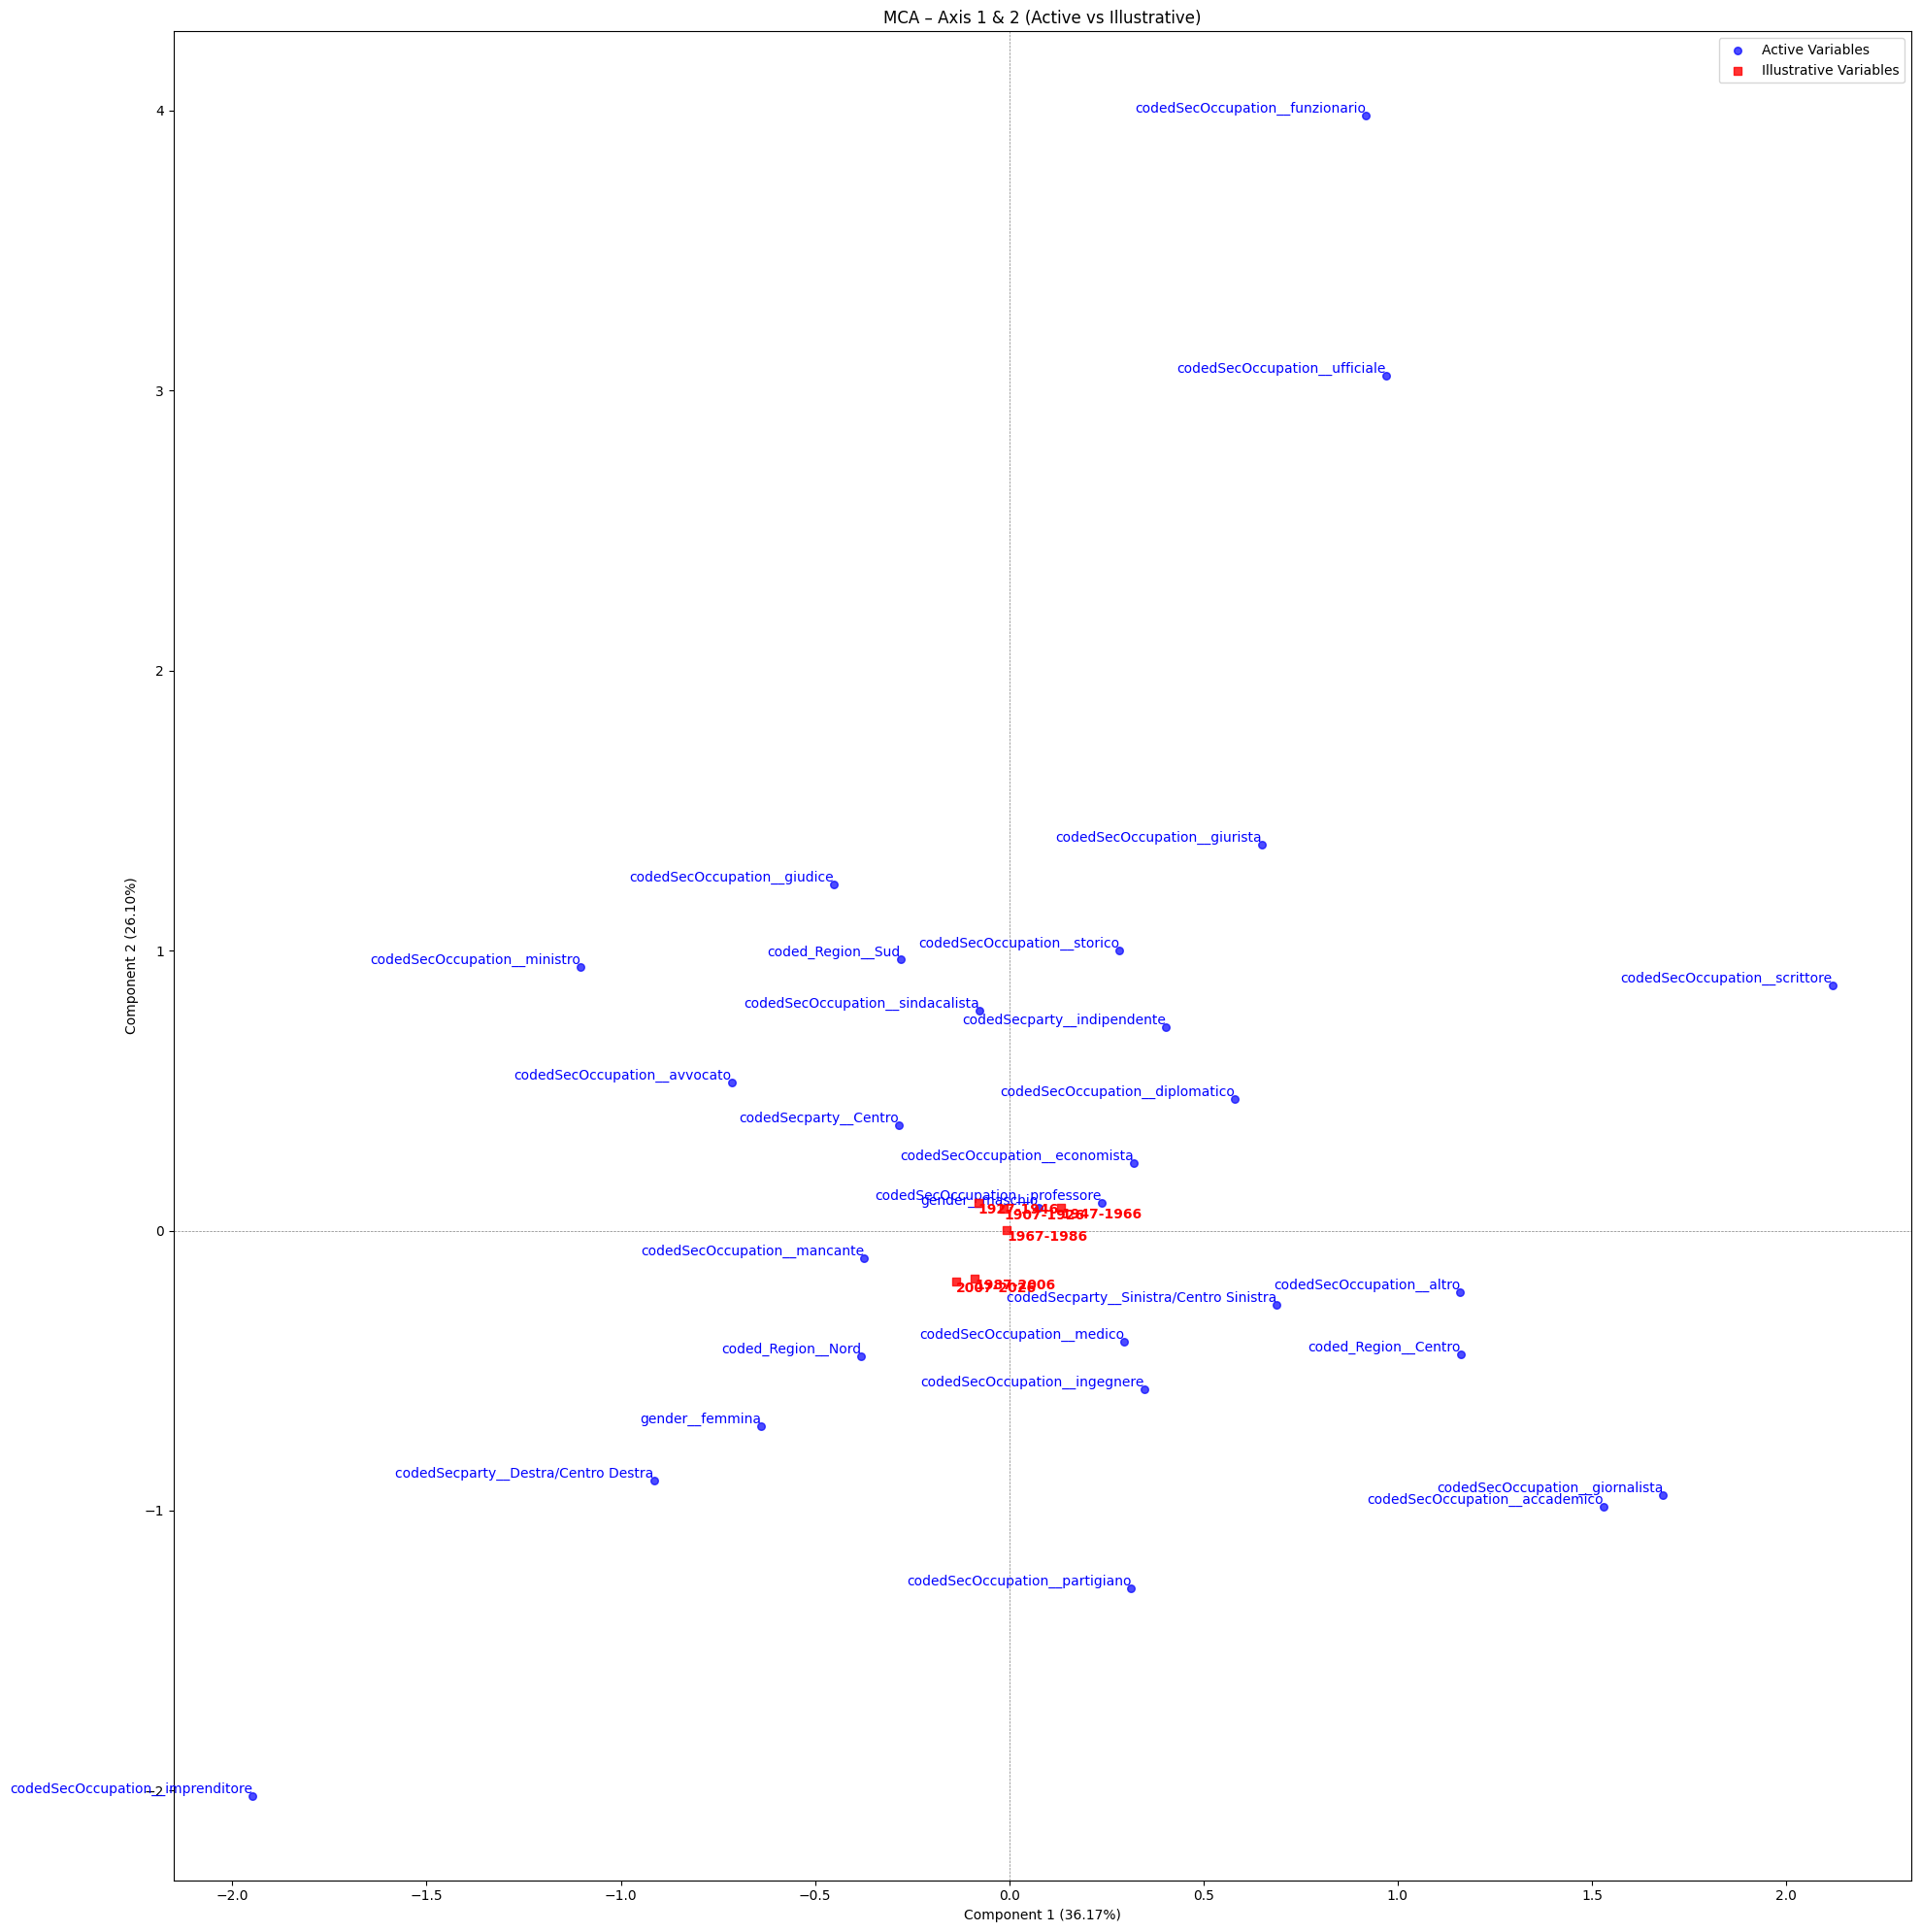

In [31]:
### dimensions
d1=1 # 0
d2=2 # 1

# Create the plot
fig, ax = plt.subplots(figsize=(20, 20))

# Plot Active Variables (Blue/Grey default)
ax.scatter(dfcc[d1], dfcc[d2], s=30, alpha=0.7, c='blue', label='Active Variables', zorder=3)

# Label Active Variables
for label, x, y in zip(dfcc.index, dfcc[d1], dfcc[d2]):
    ax.annotate(label, (x, y), fontsize=10, ha='right', va='bottom', color='blue')

# Plot Illustrative Variables (Red)
if not df_per_activ.empty:
    ax.scatter(df_per_activ[d1], df_per_activ[d2], 
               s=30, alpha=0.8, c='red', marker='s', label='Illustrative Variables', zorder=4)
    
    # Label Illustrative Variables (optional: adjust font size/color to distinguish)
    for label, x, y in zip(df_per_activ.index, df_per_activ[d1], df_per_activ[d2]):
        ax.annotate(label, (x, y), fontsize=10, ha='left', va='top', color='red', fontweight='bold')

# Add reference lines
ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.5, linestyle='--')

# Set labels and title
ax.set_xlabel(f"Component 1 ({ax1})") # Formatting percentage if applicable
ax.set_ylabel(f"Component 2 ({ax2})")
ax.set_title("MCA – Axis 1 & 2 (Active vs Illustrative)")

# Add legend to distinguish groups
ax.legend(loc='best')

# Save the figure
img_address='doc_images/mca_prince_with_periods.png'
plt.savefig(img_address, dpi=150, bbox_inches='tight')

plt.tight_layout()
plt.show()

### Ascendant hierarchical classification


We observe that some variation is present in the population but it is hard to identify using MCA the relevant profiles.

We therefore will use the K-means machine learning methodology to create clusters using the positions in the geometric space calculated with MCA.


* We first inspect and choose the optimal clustering level using a hierarchical classificaion
* We the apply two other techniques to decide the optimal clustering level: Elbow vs Silouette scores

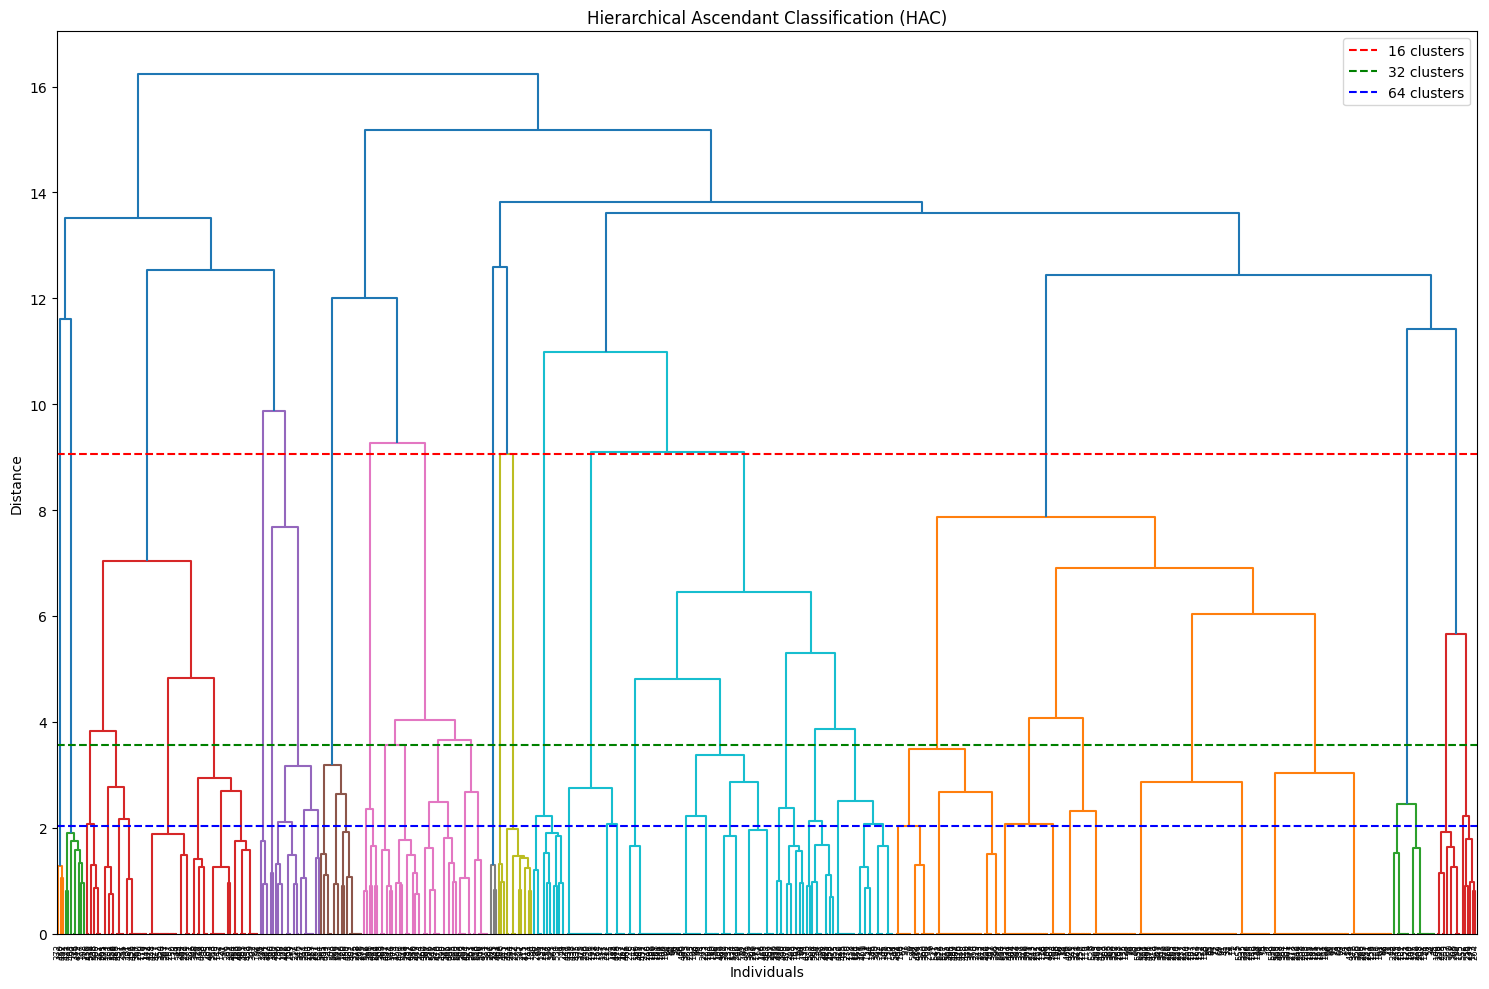

In [32]:

Z = sch.linkage(X_mca, method='ward')

# --- Dendrogram with cut lines ---
fig, ax = plt.subplots(figsize=(15, 10))

sch.dendrogram(Z, labels=df_pm.index.tolist(), leaf_rotation=90, 
               leaf_font_size=6, ax=ax)

dfs = {}

# Add horizontal cut lines for  clusters
colors = {'16 clusters': 'red', '32 clusters': 'green', '64 clusters': 'blue'}
for clusters_n, color in zip([16, 32, 64], ['red', 'green', 'blue']):
    cut_height = sch.dendrogram(Z, no_plot=True)['dcoord']

    labels = fcluster(Z, t=clusters_n, criterion='maxclust')

    dfs[clusters_n] = df_pm.assign(cluster=labels)

    # get the threshold height for this number of clusters
    threshold = sorted(Z[:, 2], reverse=True)[clusters_n - 1]
    ax.axhline(y=threshold, color=color, linestyle='--', 
               label=f'{clusters_n} clusters')

ax.set_title("Hierarchical Ascendant Classification (HAC)")
ax.set_xlabel("Individuals")
ax.set_ylabel("Distance")
ax.legend()
plt.tight_layout()
plt.show()

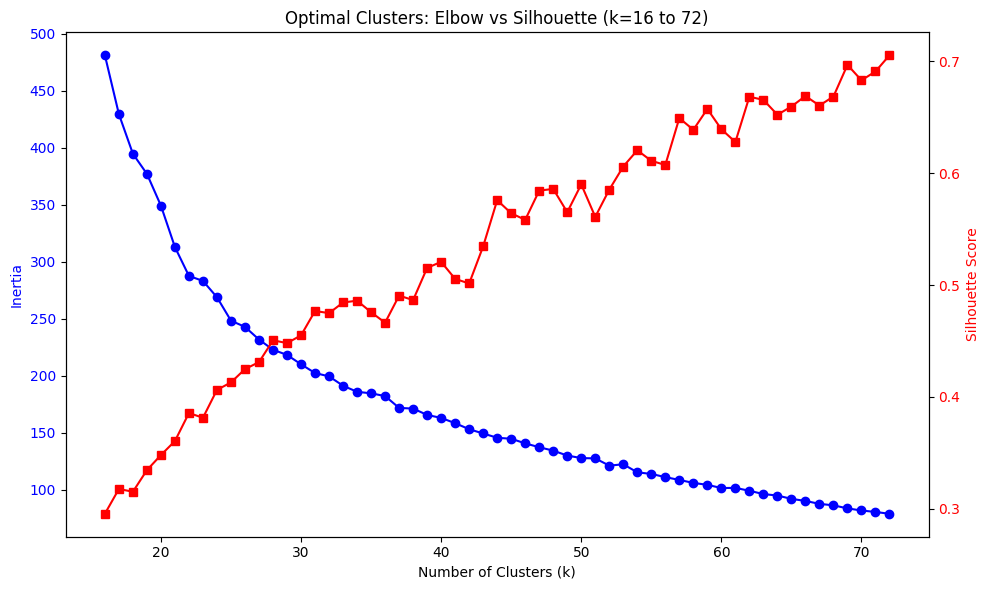

Best k by Silhouette: 72 (Score: 0.706)


In [33]:
### Test best clustering k
# we test from 2x8 to 9x8, althoug we'll use 64

# 2. Define cluster range
k_range = range(16, 73)

# 3. Calculate Inertia and Silhouette Scores
inertias = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_mca)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_mca, labels))

# 4. Plot results
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(k_range, inertias, 'bo-', label='Inertia (Elbow)')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia', color='b')
ax1.tick_params(axis='y', labelcolor='b')

ax2 = ax1.twinx()
ax2.plot(k_range, silhouette_scores, 'rs-', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='r')
ax2.tick_params(axis='y', labelcolor='r')

plt.title('Optimal Clusters: Elbow vs Silhouette (k=16 to 72)')
fig.tight_layout()
plt.show()

# 5. Identify best k
best_k_silhouette = k_range[np.argmax(silhouette_scores)]
print(f"Best k by Silhouette: {best_k_silhouette} (Score: {max(silhouette_scores):.3f})")

## Define clusters with same number as K-mode to compare


We observe that there is no clear distinction of profiles in the whole population. 

The elbow could be situated at 30-32 clusters but further splitting produces even more precise results, indicating the present of smaller different profiles.

We therefore take the heuristic stance to inspect three numbers of clusters that are multiples of our 8 periods: 16, 32, 64. 

We will the observe if the splitting allow to detect some more clear correlation with periods



In [34]:
### choose your number of clusters

# k = 16
k = 32
# k = 64

In [35]:
### We activate the machine learning object

kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)


In [36]:
### We activate the machine learning process that creates the clusters
#  X_mca: coordinates of individuals/rows, cf. above
kmeans.fit(X_mca)


,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",32
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",20
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [37]:
### Assign cluster labels to the coordinates dataframe
# each row represents an individual
X_mca["cluster"] = kmeans.labels_


In [38]:
### Result of clustering
# The index is the individuals' index
# The cluster label (as integer) is added to the coordinates in the MCA space
print('Number of rows:', len(X_mca))
X_mca.head()

Number of rows: 561


,0,1,2,3,4,5,6,7,8,9,cluster
0,-0.386804,0.129781,0.067008,1.123505,1.003600,1.024100,1.195317,-0.971840,-0.538426,-0.297676,9
1,-0.299877,1.066600,-0.067761,-0.052153,-0.079009,-0.420307,-1.048647,1.581477,0.716160,-0.061669,13
2,-0.423890,-0.410308,-0.038532,0.377465,-0.225275,-0.419763,0.082631,-0.062126,0.030245,-0.000871,1
3,0.081528,-0.824032,-0.317842,-0.234726,-0.297774,0.484738,-0.188685,-0.060381,-0.095628,0.104758,19
4,-0.179567,-0.141754,-0.044903,0.293555,0.149330,0.433472,-0.188685,-0.060381,-0.095628,0.104758,22


In [39]:
### We add the cluster to the categories table of the active variables
# Take only the first 5 columns and exclude the new 'cluster' column
clusters = kmeans.fit_predict(X_mca.iloc[:,:10])
df_actives['cluster']=clusters

In [40]:
print('Number of rows:', len(df_actives))
df_actives.head()

Number of rows: 561


,gender,coded_Region,codedSecOccupation,codedSecparty,cluster
0,maschio,Nord,sindacalista,Sinistra/Centro Sinistra,9
1,maschio,Centro,diplomatico,Sinistra/Centro Sinistra,13
2,maschio,Nord,mancante,Centro,1
3,maschio,Nord,avvocato,Destra/Centro Destra,19
4,maschio,Nord,avvocato,Sinistra/Centro Sinistra,22


### Get the Cluster Profiles (e.g., "Cluster 0 = male, Italy, university-teacher,GLAM")

Get the geometric center of coordinates of the cluster and join with the mode, i.e. the most frequent category set in the cluster

In [41]:
# Get the numeric centroid (average of dimensions in clusters)
numeric_centroids = pd.DataFrame(kmeans.cluster_centers_, columns=['dim_1', 'dim_2', 'dim_3', 'dim_4','dim_5','dim_6', 'dim_7', 'dim_8', 'dim_9','dim_10'])
numeric_centroids.index.name = 'Cluster_ID'
numeric_centroids.head()

,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,dim_8,dim_9,dim_10
Cluster_ID,,,,,,,,,,
0,-0.363997,0.055911,0.374408,-0.020177,0.382684,0.224723,-0.028184,-0.052032,-0.052756,0.044237
1,-0.336225,-0.407168,0.030810,0.333803,-0.236030,-0.358285,-0.015480,-0.053867,-0.040959,0.038924
2,1.462879,0.262162,0.369698,0.666103,-0.660039,0.016284,0.220856,0.154234,-0.196585,-0.479531
3,-0.303123,0.753312,-0.284191,-0.100374,0.164432,-0.212363,-0.027087,-0.040648,-0.090607,0.046196
4,-1.015226,1.240835,0.498970,-0.691733,-0.833310,-1.199942,2.763227,-0.555652,2.721793,-2.621635


In [42]:
### Calculate the categorical profile (Mode of each variable per cluster)
# We use here the mode, i.e. the most frequent set in each cluster
categorical_centroids = df_actives.groupby('cluster').agg(lambda x: x.mode()[0])
categorical_centroids.head()

,gender,coded_Region,codedSecOccupation,codedSecparty
cluster,,,,
0,maschio,Sud,mancante,Sinistra/Centro Sinistra
1,maschio,Nord,mancante,Centro
2,maschio,Nord,economista,indipendente
3,maschio,Centro,mancante,Sinistra/Centro Sinistra
4,maschio,Centro,scrittore,Centro


In [43]:
### size of the clusters
dfg = pd.DataFrame(df_actives.groupby(by=['cluster']).size())
dfg.columns=['number_in_cl']
dfg.sort_values(by='number_in_cl', ascending=False).head()


,number_in_cl
cluster,
1,61
20,39
19,37
22,35
10,31


In [44]:
### Join to cluster modes the number of individuals in the cluster 
# Beware: not all share the mode !
categorical_centroids=categorical_centroids.join(dfg)

In [45]:
categorical_centroids.sort_values('number_in_cl', ascending=False)

,gender,coded_Region,codedSecOccupation,codedSecparty,number_in_cl
cluster,,,,,
1,maschio,Nord,mancante,Centro,61
20,maschio,Sud,mancante,Centro,39
19,maschio,Nord,mancante,Destra/Centro Destra,37
22,maschio,Nord,mancante,Sinistra/Centro Sinistra,35
10,femmina,Sud,mancante,Centro,31
0,maschio,Sud,mancante,Sinistra/Centro Sinistra,31
24,maschio,Centro,mancante,Centro,27
25,maschio,Sud,avvocato,Centro,27
30,maschio,Centro,giornalista,Centro,27


In [46]:

# Merge the cluster modes with the nummerical centroids 
cluster_profiles = pd.concat([categorical_centroids,numeric_centroids], axis=1)

In [47]:
### Inspect
cluster_profiles.head(3)

,gender,coded_Region,codedSecOccupation,codedSecparty,number_in_cl,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,dim_8,dim_9,dim_10
0,maschio,Sud,mancante,Sinistra/Centro Sinistra,31,-0.363997,0.055911,0.374408,-0.020177,0.382684,0.224723,-0.028184,-0.052032,-0.052756,0.044237
1,maschio,Nord,mancante,Centro,61,-0.336225,-0.407168,0.030810,0.333803,-0.236030,-0.358285,-0.015480,-0.053867,-0.040959,0.038924
2,maschio,Nord,economista,indipendente,17,1.462879,0.262162,0.369698,0.666103,-0.660039,0.016284,0.220856,0.154234,-0.196585,-0.479531


In [48]:
### Create a label with the mode categories
cluster_profiles['label'] = cluster_profiles.apply(
    lambda x: str(x.name) + "_" + "_".join(x[['gender', 'coded_Region', 'codedSecOccupation', 'codedSecparty']].astype(str)), 
    axis=1
)
cluster_profiles[['label', 'number_in_cl']].head(3)

,label,number_in_cl
0,0_maschio_Sud_mancante_Sinistra/Centro Sinistra,31
1,1_maschio_Nord_mancante_Centro,61
2,2_maschio_Nord_economista_indipendente,17


In [49]:
### Inspect the already created illustrative variable 'per_act'
df_per_activ

,number,0,1,2,3,4,5,6,7,8,9
periodsActivity,,,,,,,,,,,
1907-1926,41,-0.117335,-0.013653,0.079794,0.076869,-0.176766,0.054095,-0.039336,-0.061098,-0.028843,-0.022510
1927-1946,70,-0.214402,-0.080179,0.099953,0.170114,-0.116891,-0.100343,-0.056824,0.068896,-0.024407,0.075278
1947-1966,152,-0.204631,0.134170,0.082380,0.112261,-0.071219,-0.007116,-0.009542,-0.035940,0.004762,0.066145
1967-1986,166,0.202661,-0.005607,0.002310,0.025655,0.054068,0.082834,0.008593,-0.011075,0.011107,-0.094270
1987-2006,99,0.212097,-0.088712,-0.173206,-0.275877,0.057747,0.022429,0.060842,0.059527,0.007539,0.014185
2007-2026,33,-0.112622,-0.136618,-0.182610,-0.274850,0.350389,-0.305549,-0.012389,-0.027559,-0.012815,-0.004726


### Plot the cluster profiles

In [50]:
### Get the inertia proportion for the first two axis
ax1=mca.eigenvalues_summary.iloc[0, 1]
ax2=mca.eigenvalues_summary.iloc[1, 1]

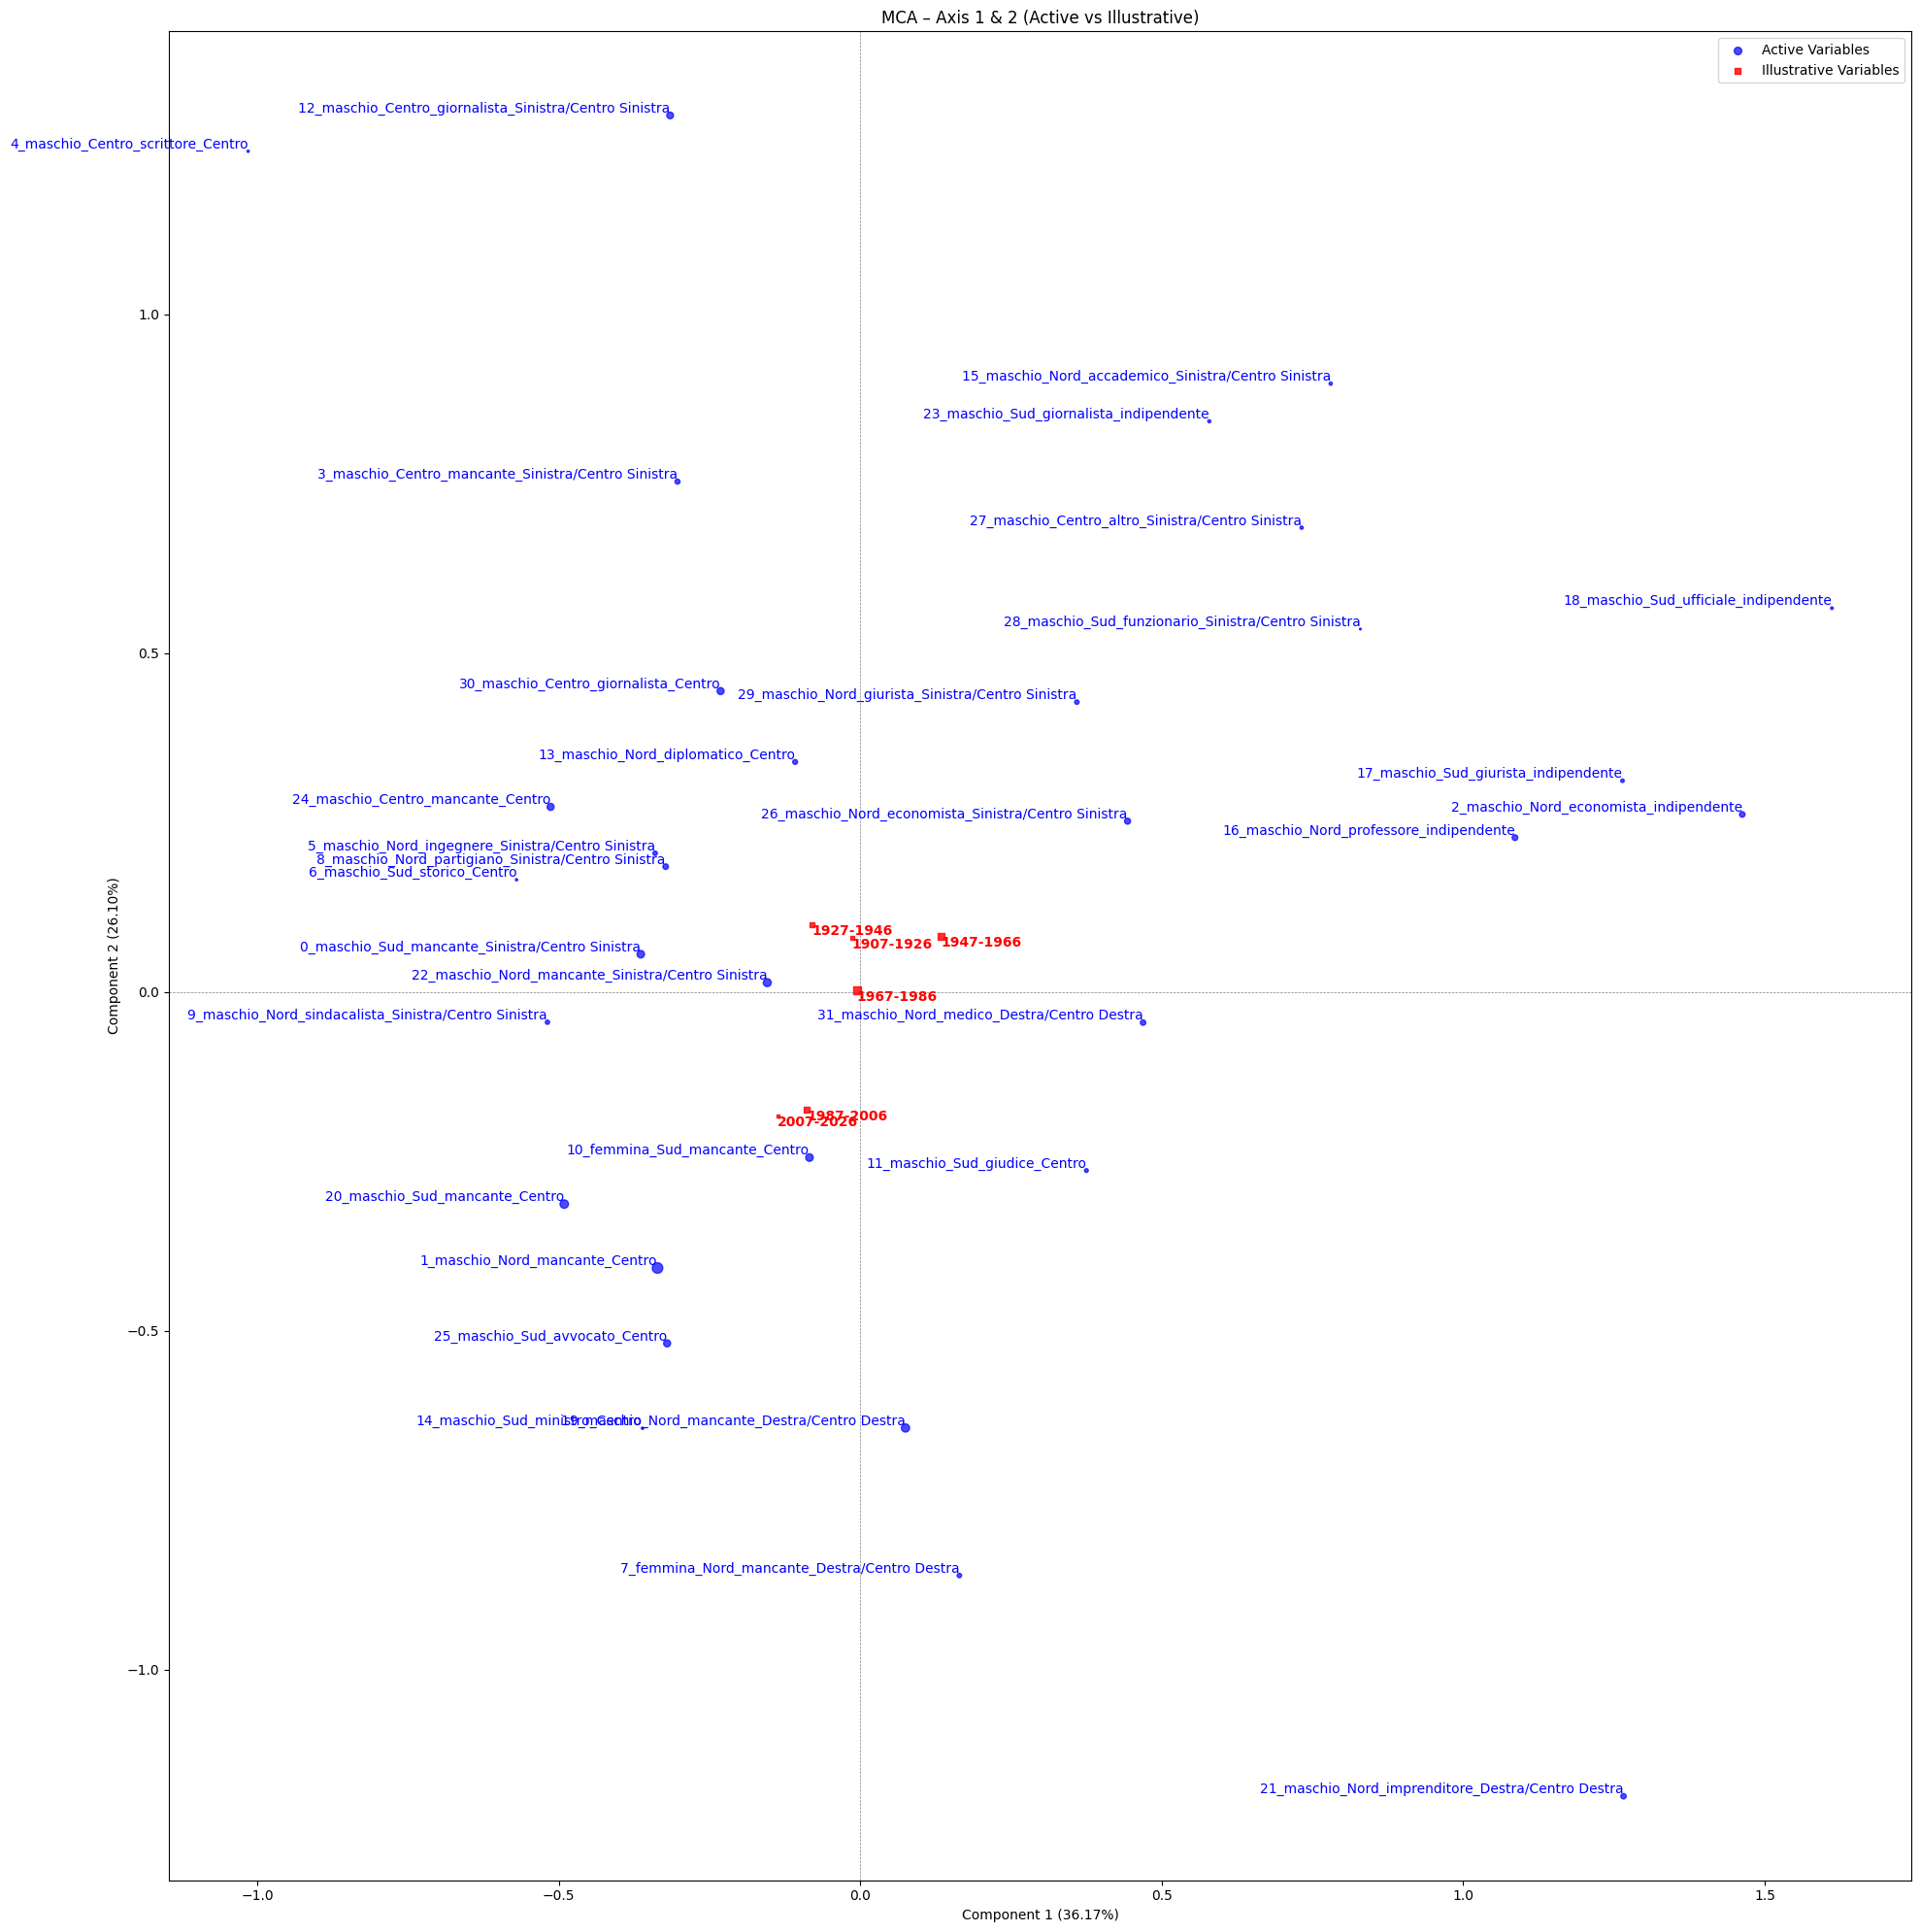

In [51]:

# Get coordinates for illustrative variables
# Note: Ensure 'df_illustrative' contains the column names of your illustrative variables
df_illust_coords = mca.column_coordinates(df_illustrative)

# Create the plot
fig, ax = plt.subplots(figsize=(20, 20))

# Plot Active Variables (Blue/Grey default)
ax.scatter(cluster_profiles['dim_1'], cluster_profiles['dim_2'], 
           s=cluster_profiles['number_in_cl'], alpha=0.7, c='blue', label='Active Variables', zorder=3)

# Label Active Variables
for label, x, y in zip(cluster_profiles.label, cluster_profiles['dim_1'], cluster_profiles['dim_2']):
    ax.annotate(label, (x, y), fontsize=10, ha='right', va='bottom', color='blue')

# Plot Illustrative Variables (Red)
if not df_per_activ.empty:
    ax.scatter(df_per_activ[1], df_per_activ[2], 
               s=df_per_activ['number']/5, alpha=0.8, c='red', marker='s', label='Illustrative Variables', zorder=4)
    
    # Label Illustrative Variables (optional: adjust font size/color to distinguish)
    for label, x, y in zip(df_per_activ.index, df_per_activ[1], df_per_activ[2]):
        ax.annotate(label, (x, y), fontsize=10, ha='left', va='top', color='red', fontweight='bold')

# Add reference lines
ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.5, linestyle='--')

# Set labels and title
ax.set_xlabel(f"Component 1 ({ax1})") # Formatting percentage if applicable
ax.set_ylabel(f"Component 2 ({ax2})")
ax.set_title("MCA – Axis 1 & 2 (Active vs Illustrative)")

# Add legend to distinguish groups
ax.legend(loc='best')

# Save the figure
img_address='doc_images/mca_prince_with_clusters.png'
plt.savefig(img_address, dpi=150, bbox_inches='tight')

plt.tight_layout()
plt.show()

### Single Most Representative Person (e.g., "Cluster 1 is best represented by Person ").

This is a different way of interpreting the clusters: find the person that is at the center of the MCA coordinates in the cluster. It is threfore somehow representative of the cluster

In [52]:


# --- 1. SETUP (Assuming you already have these) ---
# dfa: DataFrame with MCA coordinates (numeric)
# cluster_labels: The result from KMeans.fit_predict()
# centroids: The result from kmeans.cluster_centers_


# Store results here
medoid_results = []

# --- 2. LOOP THROUGH EACH CLUSTER ---
unique_clusters = sorted(df_actives['cluster'].unique())

for k in unique_clusters:
    # A. Filter data: Get ONLY rows belonging to this specific cluster
    cluster_mask = df_actives['cluster'] == k
    cluster_members = df_actives[cluster_mask]
    
    # B. Get the specific centroid for this cluster
    # centroids is a numpy array, so we take row k
    current_centroid = numeric_centroids.iloc[k].values.reshape(1, -1) # Reshape to 2D for cdist
    
    # C. Calculate distances: Members vs. Their Own Centroid
    # We exclude the 'Cluster' column from calculation if it exists in cluster_members
    coords_only = X_mca.iloc[:, :-1] # Assumes last col is 'Cluster'
    
    distances = cdist(coords_only, current_centroid, metric='euclidean')
    
    # D. Find the index of the minimum distance within this subset
    min_dist_idx = distances.argmin()
    
    # E. Retrieve the ORIGINAL dataframe index of this person
    # cluster_members.index[min_dist_idx] gives the real ID from the original df
    original_index = X_mca.index[min_dist_idx]
    
    # F. Save results
    medoid_results.append({
        'Cluster_ID': k,
        'Medoid_Original_Index': original_index,
        'Min_Distance': distances[min_dist_idx][0]
    })

# --- 3. CREATE RESULT TABLE ---
medoid_df = pd.DataFrame(medoid_results)

# --- 4. DISPLAY WITH CATEGORIES ---
# Merge back with original data to see the actual categories (Age, City, etc.)
# Replace 'original_df' with the name of your raw categorical dataframe
medoids = medoid_df.merge(df_actives, left_on='Medoid_Original_Index', right_index=True, how='left')

print("Single Most Representative Person (Medoid) per Cluster:")
medoids

Single Most Representative Person (Medoid) per Cluster:


,Cluster_ID,Medoid_Original_Index,Min_Distance,gender,coded_Region,codedSecOccupation,codedSecparty,cluster
0,0,89,0.209481,maschio,Sud,mancante,Sinistra/Centro Sinistra,0
1,1,2,0.186152,maschio,Nord,mancante,Centro,1
2,2,13,0.208242,maschio,Nord,economista,indipendente,2
3,3,114,0.277271,maschio,Centro,mancante,Sinistra/Centro Sinistra,3
4,4,335,0.374450,maschio,Centro,scrittore,Centro,4
5,5,227,0.464021,maschio,Nord,ingegnere,Sinistra/Centro Sinistra,5
6,6,452,0.573186,maschio,Sud,storico,Sinistra/Centro Sinistra,6
7,7,527,0.399890,femmina,Nord,avvocato,Destra/Centro Destra,7
8,8,34,0.339634,maschio,Nord,partigiano,Sinistra/Centro Sinistra,8
9,9,40,0.492996,maschio,Sud,sindacalista,Sinistra/Centro Sinistra,9


#### Inspect frequency of individuals identical with centroid

In [53]:
### this dataframe contains only rows that are identical with the centroid in each cluster
merged_df = df_actives.merge(medoids, on=['gender', 'coded_Region', 'codedSecOccupation', 'codedSecparty', 'cluster'], how='inner')

In [54]:
### Persons with medoid value in proportion to population

# only persons identical to centroids of their cluster
print(len(merged_df))

# all the persons
print(len(df_pm))


# frequency
print(str(round((len(merged_df)/len(df_pm)*100),1))+' %')


262
561
46.7 %


#### Inspect with identical cluster profile (modes)

In [55]:
clu_prof=cluster_profiles.reset_index(names='cluster')
print(len(clu_prof))
clu_prof.head()

32


,cluster,gender,coded_Region,codedSecOccupation,codedSecparty,number_in_cl,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,dim_8,dim_9,dim_10,label
0,0,maschio,Sud,mancante,Sinistra/Centro Sinistra,31,-0.363997,0.055911,0.374408,-0.020177,0.382684,0.224723,-0.028184,-0.052032,-0.052756,0.044237,0_maschio_Sud_mancante_Sinistra/Centro Sinistra
1,1,maschio,Nord,mancante,Centro,61,-0.336225,-0.407168,0.030810,0.333803,-0.236030,-0.358285,-0.015480,-0.053867,-0.040959,0.038924,1_maschio_Nord_mancante_Centro
2,2,maschio,Nord,economista,indipendente,17,1.462879,0.262162,0.369698,0.666103,-0.660039,0.016284,0.220856,0.154234,-0.196585,-0.479531,2_maschio_Nord_economista_indipendente
3,3,maschio,Centro,mancante,Sinistra/Centro Sinistra,14,-0.303123,0.753312,-0.284191,-0.100374,0.164432,-0.212363,-0.027087,-0.040648,-0.090607,0.046196,3_maschio_Centro_mancante_Sinistra/Centro Sini...
4,4,maschio,Centro,scrittore,Centro,3,-1.015226,1.240835,0.498970,-0.691733,-0.833310,-1.199942,2.763227,-0.555652,2.721793,-2.621635,4_maschio_Centro_scrittore_Centro


In [56]:
print(len(df_actives))

561


In [57]:
### this dataframe contains only rows that are identical with the centroid in each cluster
merged_df_prof = df_actives.merge(clu_prof, on=['gender', 'coded_Region', 'codedSecOccupation', 'codedSecparty', 'cluster'], how='inner')

In [58]:
### Persons with medoid value in proportion to population

# only persons identical to centroids of their cluster
print(len(merged_df_prof))

# all the persons
print(len(df_pm))
cluster_profiles

# frequency
print(str(round((len(merged_df_prof)/len(df_pm)*100),1))+' %')


260
561
46.3 %


#### Keep the clu_prof 

We keep the first methodology to define the cluster center, based on modes.

But we observe from different runs for 16,32 and 64 cluster, that smalle clusters tend to be nearer to the mean profile (vs the mode)

In [59]:
clu_prof.head()

,cluster,gender,coded_Region,codedSecOccupation,codedSecparty,number_in_cl,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,dim_8,dim_9,dim_10,label
0,0,maschio,Sud,mancante,Sinistra/Centro Sinistra,31,-0.363997,0.055911,0.374408,-0.020177,0.382684,0.224723,-0.028184,-0.052032,-0.052756,0.044237,0_maschio_Sud_mancante_Sinistra/Centro Sinistra
1,1,maschio,Nord,mancante,Centro,61,-0.336225,-0.407168,0.030810,0.333803,-0.236030,-0.358285,-0.015480,-0.053867,-0.040959,0.038924,1_maschio_Nord_mancante_Centro
2,2,maschio,Nord,economista,indipendente,17,1.462879,0.262162,0.369698,0.666103,-0.660039,0.016284,0.220856,0.154234,-0.196585,-0.479531,2_maschio_Nord_economista_indipendente
3,3,maschio,Centro,mancante,Sinistra/Centro Sinistra,14,-0.303123,0.753312,-0.284191,-0.100374,0.164432,-0.212363,-0.027087,-0.040648,-0.090607,0.046196,3_maschio_Centro_mancante_Sinistra/Centro Sini...
4,4,maschio,Centro,scrittore,Centro,3,-1.015226,1.240835,0.498970,-0.691733,-0.833310,-1.199942,2.763227,-0.555652,2.721793,-2.621635,4_maschio_Centro_scrittore_Centro


In [60]:
print(len(merged_df_prof))
merged_df_prof.head(2)

260


,gender,coded_Region,codedSecOccupation,codedSecparty,cluster,number_in_cl,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,dim_8,dim_9,dim_10,label
0,maschio,Nord,sindacalista,Sinistra/Centro Sinistra,9,10,-0.518804,-0.044473,0.452817,0.824448,0.986488,0.876926,1.195317,-0.971840,-0.538426,-0.297676,9_maschio_Nord_sindacalista_Sinistra/Centro Si...
1,maschio,Nord,mancante,Centro,1,61,-0.336225,-0.407168,0.030810,0.333803,-0.236030,-0.358285,-0.015480,-0.053867,-0.040959,0.038924,1_maschio_Nord_mancante_Centro


In [61]:
### Count per cluster how many rows have same values as centroid
dfcen = pd.DataFrame(merged_df_prof.groupby(by=['cluster']).size())
dfcen.columns=['n_cluster']
dfcen.sort_values(by='n_cluster', ascending=False).head()

,n_cluster
cluster,
1,40
20,31
19,19
0,19
24,18


In [62]:
### How many rows in total have gender:female
dfgf = pd.DataFrame(df_actives[df_actives.gender=='femmina'].groupby(by=['cluster']).size())
dfgf.columns=['number_f']
(print(dfgf.sort_values(by='number_f', ascending=False).iloc[:30]))

         number_f
cluster          
10             31
7              11
21              4
16              3
15              2
11              1
9               1
8               1
13              1
12              1
17              1
27              1
29              1


In [63]:
### Add cluster to df_pm
df_pm=df_pm.join(df_actives, rsuffix='_r')

In [64]:
df_pm.head(2)

,person_uri,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,index_right,REGION,reg_istat_num,reg_istat_code,coded_Region,activityYear,periodsActivity,pk_person_features,occupation_main,occup_sec1,occup_sec2,party,fk_person,codedSecOccupation,codedSecparty,gender_r,coded_Region_r,codedSecOccupation_r,codedSecparty_r,cluster
0,http://www.wikidata.org/entity/Q3839099,Ludovico D'Aragona,1876.0,maschio,Cernusco sul Naviglio,POINT (9.333333 45.516667),http://www.wikidata.org/entity/Q185619,1871-1880,2.0,Lombardia,3.0,3.0,Nord,1911.0,1907-1926,355,politico,sindacalista,mancante,Partito Socialista Italiano,355,sindacalista,Sinistra/Centro Sinistra,maschio,Nord,sindacalista,Sinistra/Centro Sinistra,9
1,http://www.wikidata.org/entity/Q463243,Carlo Sforza,1872.0,maschio,Montignoso,POINT (10.166667 44.016667),http://www.wikidata.org/entity/Q52236,1871-1880,8.0,Toscana,9.0,9.0,Centro,1907.0,1907-1926,461,politico,diplomatico,mancante,Partito Repubblicano Italiano,461,diplomatico,Sinistra/Centro Sinistra,maschio,Centro,diplomatico,Sinistra/Centro Sinistra,13


In [65]:
### Group and count countries in clusters

# countries per cluster
result_df = pd.DataFrame(df_pm.groupby(by=['cluster', 'coded_Region_r']).size()).reset_index()
result_df.columns=['cluster','coded_Region_r','number']
result_df=result_df.sort_values(['cluster','number'], ascending=[True,False])
result_df.head()


# aggregated countries per cluster
dfg_country = result_df.groupby('cluster')[['coded_Region_r', 'number']].apply(
    lambda x: x.values.tolist()
).reset_index(name='aggregated_data')

### Take the first five per cluster
dfg_country['coded_Region_list'] = dfg_country.aggregated_data.apply(
    lambda lst: ', '.join([f"{item[0]}: {item[1]}" for item in lst[:5]])
)
dfg_country=dfg_country.drop(columns=['cluster','aggregated_data'])


with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.max_colwidth', None):
    display(dfg_country.head())

,coded_Region_list
0,Sud: 31
1,Nord: 61
2,"Nord: 12, Sud: 3, Centro: 2"
3,Centro: 14
4,"Centro: 2, Sud: 1"


In [66]:
### Group and count occupations in clusters

# countries per cluster
result_df = pd.DataFrame(df_pm.groupby(by=['cluster', 'codedSecOccupation']).size()).reset_index()
result_df.columns=['cluster','codedSecOccupation','number']
result_df=result_df.sort_values(['cluster','number'], ascending=[True,False])


# aggregated occupations per cluster
dfg_occupation = result_df.groupby('cluster')[['codedSecOccupation', 'number']].apply(
    lambda x: x.values.tolist()
).reset_index(name='aggregated_data')

### Take the first five per cluster
dfg_occupation['codedSecOccupation_list'] = dfg_occupation['aggregated_data'].apply(
    lambda lst: ', '.join([f"{item[0]}: {item[1]}" for item in lst[:5]])
)
dfg_occupation=dfg_occupation.drop(columns=['cluster','aggregated_data'])

with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.max_colwidth', None):
    display(dfg_occupation.head())


,codedSecOccupation_list
0,"mancante: 19, avvocato: 7, professore: 5"
1,"mancante: 40, avvocato: 13, professore: 8"
2,economista: 17
3,"mancante: 9, professore: 5"
4,scrittore: 3


In [67]:
### Group and count employer classes in clusters

# countries per cluster
result_df = pd.DataFrame(df_pm.groupby(by=['cluster', 'codedSecparty']).size()).reset_index()
result_df.columns=['cluster','codedSecOccupation','number']
result_df=result_df.sort_values(['cluster','number'], ascending=[True,False])


# aggregated occupations per cluster
dfg_empl = result_df.groupby('cluster')[['codedSecOccupation', 'number']].apply(
    lambda x: x.values.tolist()
).reset_index(name='aggregated_data')

### Take the first five per cluster
dfg_empl['party_sec1_list'] = dfg_empl['aggregated_data'].apply(
    lambda lst: ', '.join([f"{item[0]}: {item[1]}" for item in lst[:5]])
)
dfg_empl=dfg_empl.drop(columns=['cluster','aggregated_data'])

with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.max_colwidth', None):
    display(dfg_empl.head())


,party_sec1_list
0,Sinistra/Centro Sinistra: 31
1,Centro: 61
2,indipendente: 17
3,Sinistra/Centro Sinistra: 14
4,"Centro: 2, Sinistra/Centro Sinistra: 1"


#### Join and inspect

Aggregating the former tables and counts allows to inspect the clusters and identifying the structuring elements of the clusters 

In [68]:
clu_prof.iloc[:,[1,2,3,4,5,16]].head()

,gender,coded_Region,codedSecOccupation,codedSecparty,number_in_cl,label
0,maschio,Sud,mancante,Sinistra/Centro Sinistra,31,0_maschio_Sud_mancante_Sinistra/Centro Sinistra
1,maschio,Nord,mancante,Centro,61,1_maschio_Nord_mancante_Centro
2,maschio,Nord,economista,indipendente,17,2_maschio_Nord_economista_indipendente
3,maschio,Centro,mancante,Sinistra/Centro Sinistra,14,3_maschio_Centro_mancante_Sinistra/Centro Sini...
4,maschio,Centro,scrittore,Centro,3,4_maschio_Centro_scrittore_Centro


In [69]:
clu_prof_short=clu_prof.iloc[:,[1,2,3,4,5,16]]

In [70]:
print(len(clu_prof_short))
clu_prof_short.iloc[:,[5,4]].sort_values('number_in_cl', ascending=False)

32


,label,number_in_cl
1,1_maschio_Nord_mancante_Centro,61
20,20_maschio_Sud_mancante_Centro,39
19,19_maschio_Nord_mancante_Destra/Centro Destra,37
22,22_maschio_Nord_mancante_Sinistra/Centro Sinistra,35
10,10_femmina_Sud_mancante_Centro,31
0,0_maschio_Sud_mancante_Sinistra/Centro Sinistra,31
24,24_maschio_Centro_mancante_Centro,27
25,25_maschio_Sud_avvocato_Centro,27
30,30_maschio_Centro_giornalista_Centro,27
12,12_maschio_Centro_giornalista_Sinistra/Centro ...,25


In [71]:
### Join the different dataframes using the default joining on indexes
# If an error appears in joining, restart the whole process from cenroid_df onward


clu_prof_short=clu_prof_short.join(dfcen)
clu_prof_short.rename(columns={'n_cluster': 'number_centroid'}, inplace=True)
clu_prof_short=clu_prof_short.join(dfgf).fillna(0)
clu_prof_short['number_f'] = clu_prof_short['number_f'].astype(int)
clu_prof_short['prop_f'] = clu_prof_short.apply(lambda x: (x['number_f']/x['number_in_cl']), axis=1)
clu_prof_short['prop_f']=clu_prof_short['prop_f'].round(2)
clu_prof_short=clu_prof_short.join(dfg_country)
clu_prof_short=clu_prof_short.join(dfg_occupation)
clu_prof_short=clu_prof_short.join(dfg_empl)

In [72]:
clu_prof_short.number_centroid=clu_prof_short.number_centroid.astype('int')

In [73]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.max_colwidth', None):
    display(clu_prof_short.sort_values(by='number_in_cl', ascending=False).style.set_properties(subset=['codedSecOccupation_list', 'coded_Region_list'], **{'text-align': 'left'}))

,gender,coded_Region,codedSecOccupation,codedSecparty,number_in_cl,label,number_centroid,number_f,prop_f,coded_Region_list,codedSecOccupation_list,party_sec1_list
1,maschio,Nord,mancante,Centro,61,1_maschio_Nord_mancante_Centro,40,0,0.000000,Nord: 61,"mancante: 40, avvocato: 13, professore: 8",Centro: 61
20,maschio,Sud,mancante,Centro,39,20_maschio_Sud_mancante_Centro,31,0,0.000000,Sud: 39,"mancante: 32, professore: 7","Centro: 38, indipendente: 1"
19,maschio,Nord,mancante,Destra/Centro Destra,37,19_maschio_Nord_mancante_Destra/Centro Destra,19,0,0.000000,"Nord: 30, Sud: 6, Centro: 1","mancante: 22, avvocato: 7, professore: 7, imprenditore: 1","Destra/Centro Destra: 36, Centro: 1"
22,maschio,Nord,mancante,Sinistra/Centro Sinistra,35,22_maschio_Nord_mancante_Sinistra/Centro Sinistra,18,0,0.000000,Nord: 35,"mancante: 18, avvocato: 10, professore: 7",Sinistra/Centro Sinistra: 35
10,femmina,Sud,mancante,Centro,31,10_femmina_Sud_mancante_Centro,4,31,1.000000,"Sud: 11, Centro: 10, Nord: 10","mancante: 21, professore: 6, avvocato: 4","Centro: 14, Sinistra/Centro Sinistra: 13, indipendente: 4"
0,maschio,Sud,mancante,Sinistra/Centro Sinistra,31,0_maschio_Sud_mancante_Sinistra/Centro Sinistra,19,0,0.000000,Sud: 31,"mancante: 19, avvocato: 7, professore: 5",Sinistra/Centro Sinistra: 31
24,maschio,Centro,mancante,Centro,27,24_maschio_Centro_mancante_Centro,18,0,0.000000,Centro: 27,"mancante: 18, professore: 5, avvocato: 4",Centro: 27
25,maschio,Sud,avvocato,Centro,27,25_maschio_Sud_avvocato_Centro,17,0,0.000000,Sud: 27,"avvocato: 25, medico: 2","Centro: 19, Destra/Centro Destra: 6, indipendente: 2"
30,maschio,Centro,giornalista,Centro,27,30_maschio_Centro_giornalista_Centro,0,0,0.000000,"Centro: 12, Nord: 10, Sud: 5","giornalista: 15, avvocato: 4, mancante: 4, medico: 3, professore: 1","Centro: 9, Destra/Centro Destra: 9, Sinistra/Centro Sinistra: 9"
12,maschio,Centro,giornalista,Sinistra/Centro Sinistra,25,12_maschio_Centro_giornalista_Sinistra/Centro Sinistra,15,1,0.040000,Centro: 25,giornalista: 25,"Sinistra/Centro Sinistra: 15, Destra/Centro Destra: 6, Centro: 4"


In [ ]:
pcf=df_pm[['person_uri', 'periodsActivity','gender','coded_Region','codedSecOccupation','codedSecparty','occupation_main' ]]
pcf.head()

## Test if relation between clusters and periods

In [76]:
# Validate against Generation (Illustrative Variable)
# Cross-tabulation : contingency_table

df = df_pm

observed = pd.crosstab(df['cluster'], df['periodsActivity'])


In [77]:
bl.check_chi_square_test_validity(observed)

Table valid for Chi-square test: False


In [78]:
expected=bl.bivariate_stats(observed)

Chi-square : 301.71 , dof : 155
p-value : 0.0
Inertia (Phi-square):  0.538
Cramer:  0.328


### CA

In [79]:
afc = fa.CA(row_labels=observed.index,col_labels=observed.columns)
afc.fit(observed.values)

,n_components,None
,row_labels,"Index([ 0, 1...ame='cluster')"
,col_labels,Index(['1907-...iodsActivity')
,stats,True


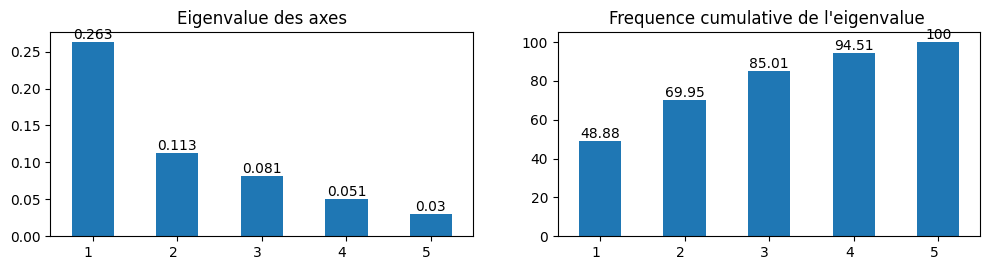

In [80]:
### Inertia (Phi-square - Eigenvalue):  0.108
cal.print_eigenvalue(afc)

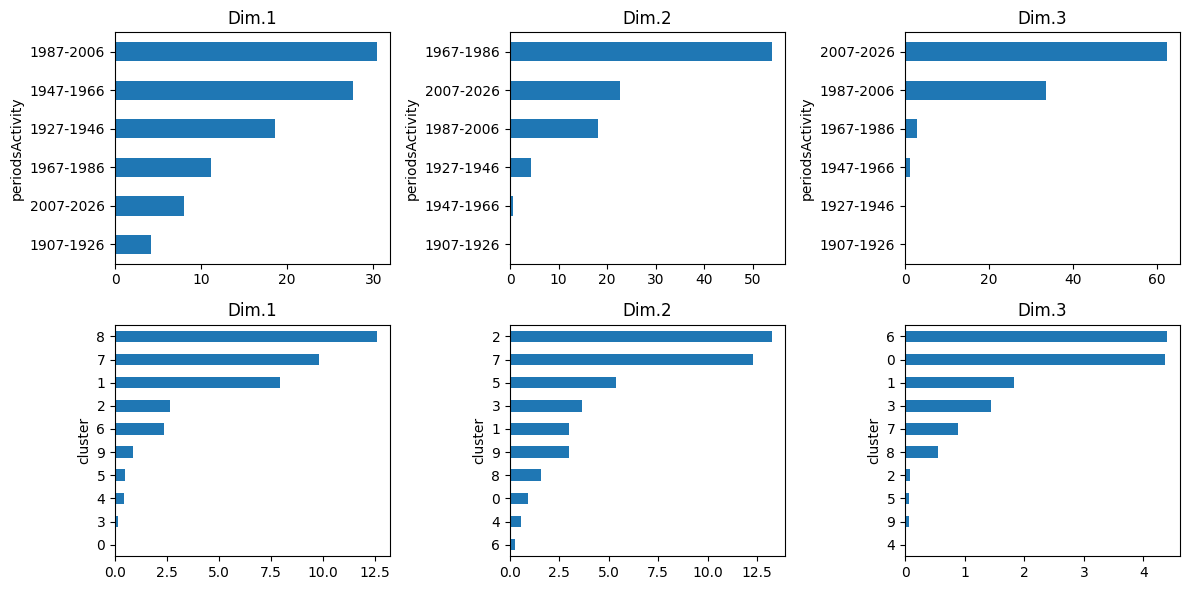

In [81]:
cal.dim_contributions(afc)

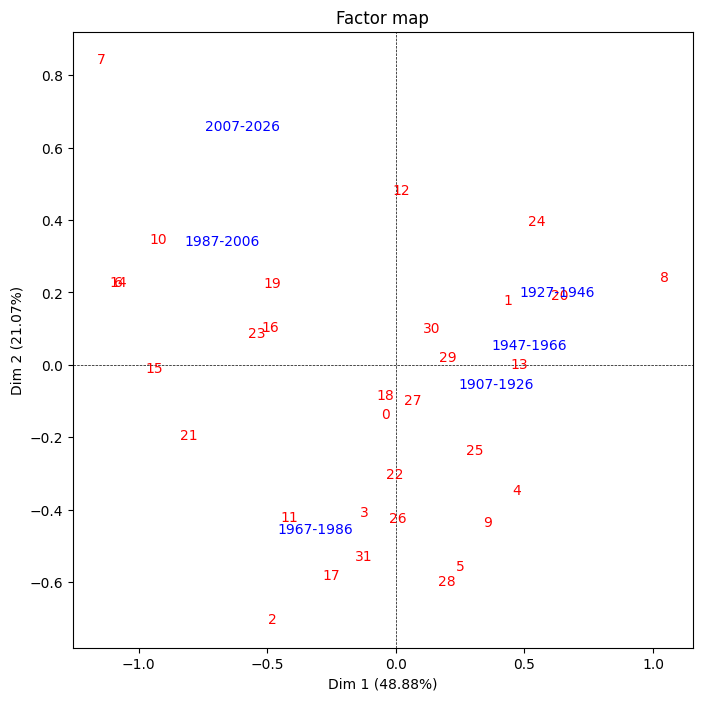

In [82]:
# Represent dimension 1 and 2
afc.mapping(num_x_axis=1,num_y_axis=2,figsize=(8,8))

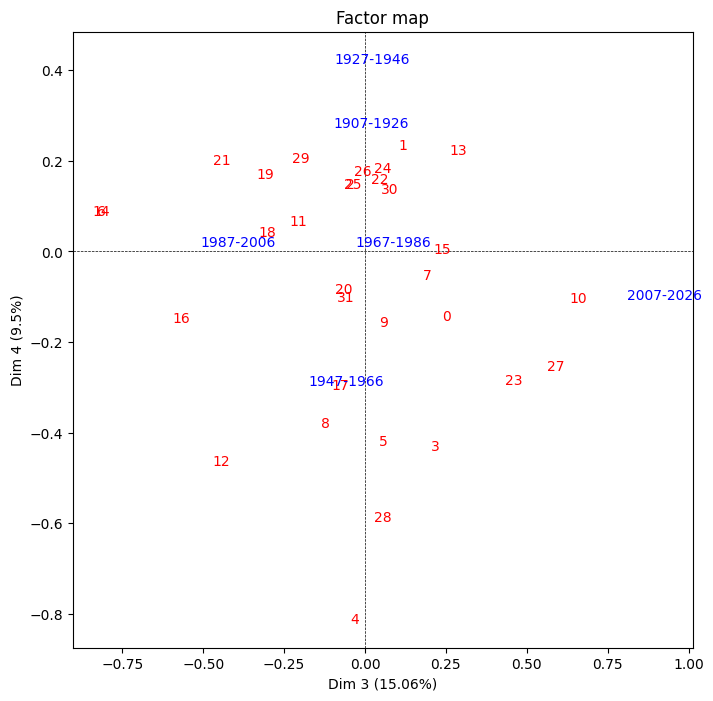

In [83]:
# Represent dimension 2 and 3
afc.mapping(num_x_axis=3,num_y_axis=4,figsize=(8,8))

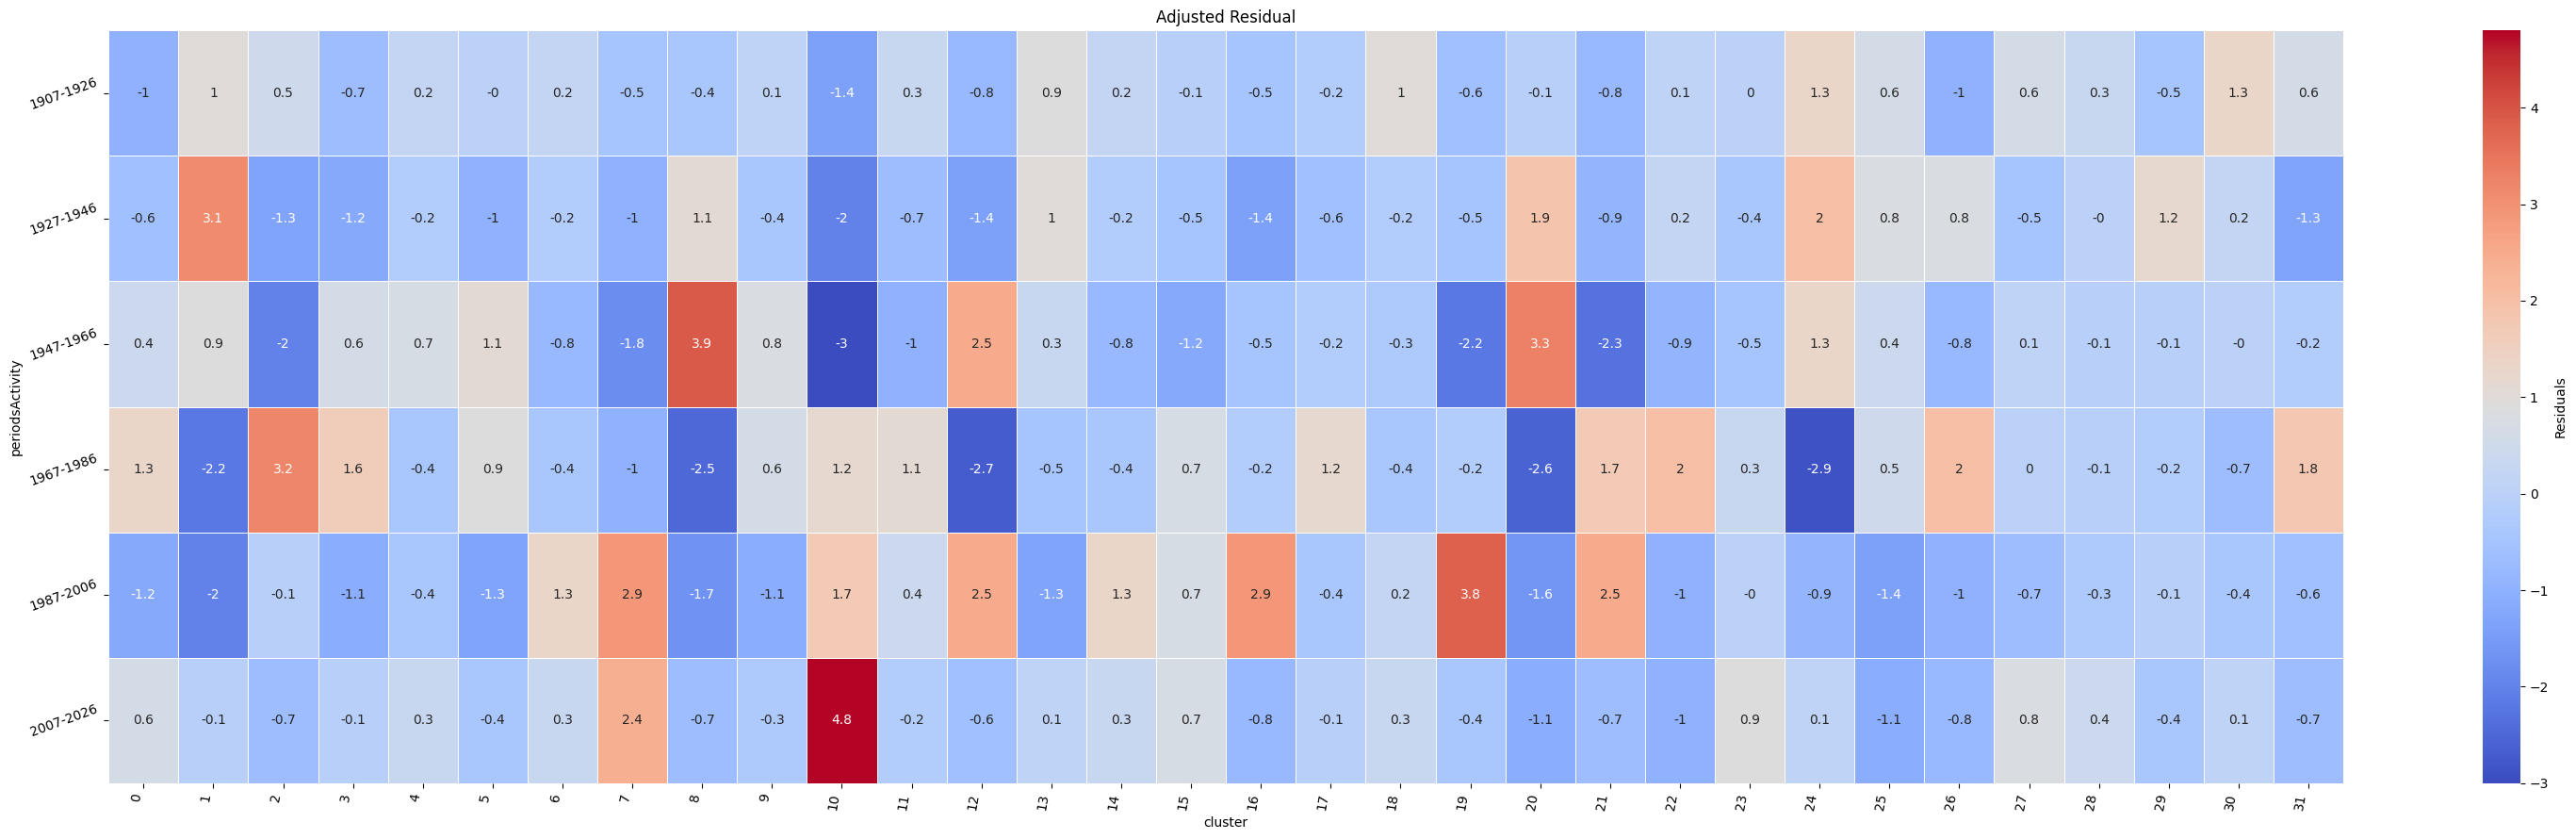

In [84]:
### Number of clusters
width= df['cluster'].max()
pp = bl.plot_chi2_residuals(observed.T, figsize=(width, 9))

In [85]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.max_colwidth', None):
    display(pd.DataFrame(clu_prof_short[['label','number_in_cl','number_centroid','number_f', 'prop_f']]))

,label,number_in_cl,number_centroid,number_f,prop_f
0,0_maschio_Sud_mancante_Sinistra/Centro Sinistra,31,19,0,0.00
1,1_maschio_Nord_mancante_Centro,61,40,0,0.00
2,2_maschio_Nord_economista_indipendente,17,12,0,0.00
3,3_maschio_Centro_mancante_Sinistra/Centro Sinistra,14,9,0,0.00
4,4_maschio_Centro_scrittore_Centro,3,1,0,0.00
5,5_maschio_Nord_ingegnere_Sinistra/Centro Sinistra,11,3,0,0.00
6,6_maschio_Sud_storico_Centro,3,0,0,0.00
7,7_femmina_Nord_mancante_Destra/Centro Destra,11,4,11,1.00
8,8_maschio_Nord_partigiano_Sinistra/Centro Sinistra,17,8,1,0.06
9,9_maschio_Nord_sindacalista_Sinistra/Centro Sinistra,10,2,1,0.10


In [86]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.max_colwidth', None):
    # Sostituiamo display() con print() e aggiungiamo .to_html() alla fine del DataFrame
    print(pd.DataFrame(clu_prof_short[['label','number_in_cl','number_centroid','number_f', 'prop_f']]).to_html(index=False))

<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th>label</th>
      <th>number_in_cl</th>
      <th>number_centroid</th>
      <th>number_f</th>
      <th>prop_f</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>0_maschio_Sud_mancante_Sinistra/Centro Sinistra</td>
      <td>31</td>
      <td>19</td>
      <td>0</td>
      <td>0.00</td>
    </tr>
    <tr>
      <td>1_maschio_Nord_mancante_Centro</td>
      <td>61</td>
      <td>40</td>
      <td>0</td>
      <td>0.00</td>
    </tr>
    <tr>
      <td>2_maschio_Nord_economista_indipendente</td>
      <td>17</td>
      <td>12</td>
      <td>0</td>
      <td>0.00</td>
    </tr>
    <tr>
      <td>3_maschio_Centro_mancante_Sinistra/Centro Sinistra</td>
      <td>14</td>
      <td>9</td>
      <td>0</td>
      <td>0.00</td>
    </tr>
    <tr>
      <td>4_maschio_Centro_scrittore_Centro</td>
      <td>3</td>
      <td>1</td>
      <td>0</td>
      <td>0.00</td>
    </tr>
    <tr>
      <td>5_masc

In [87]:
pers_cluster=df_pm[['person_uri', 'cluster']]
pers_cluster.head()

,person_uri,cluster
0,http://www.wikidata.org/entity/Q3839099,9
1,http://www.wikidata.org/entity/Q463243,13
2,http://www.wikidata.org/entity/Q3771001,1
3,http://www.wikidata.org/entity/Q1242,19
4,http://www.wikidata.org/entity/Q3839683,22


## Plot clusters

In [88]:
categorical_cols = df_actives.columns.to_list()[:4]
print(categorical_cols)

['gender', 'coded_Region', 'codedSecOccupation', 'codedSecparty']


In [89]:
df_actives.head(1)

,gender,coded_Region,codedSecOccupation,codedSecparty,cluster
0,maschio,Nord,sindacalista,Sinistra/Centro Sinistra,9


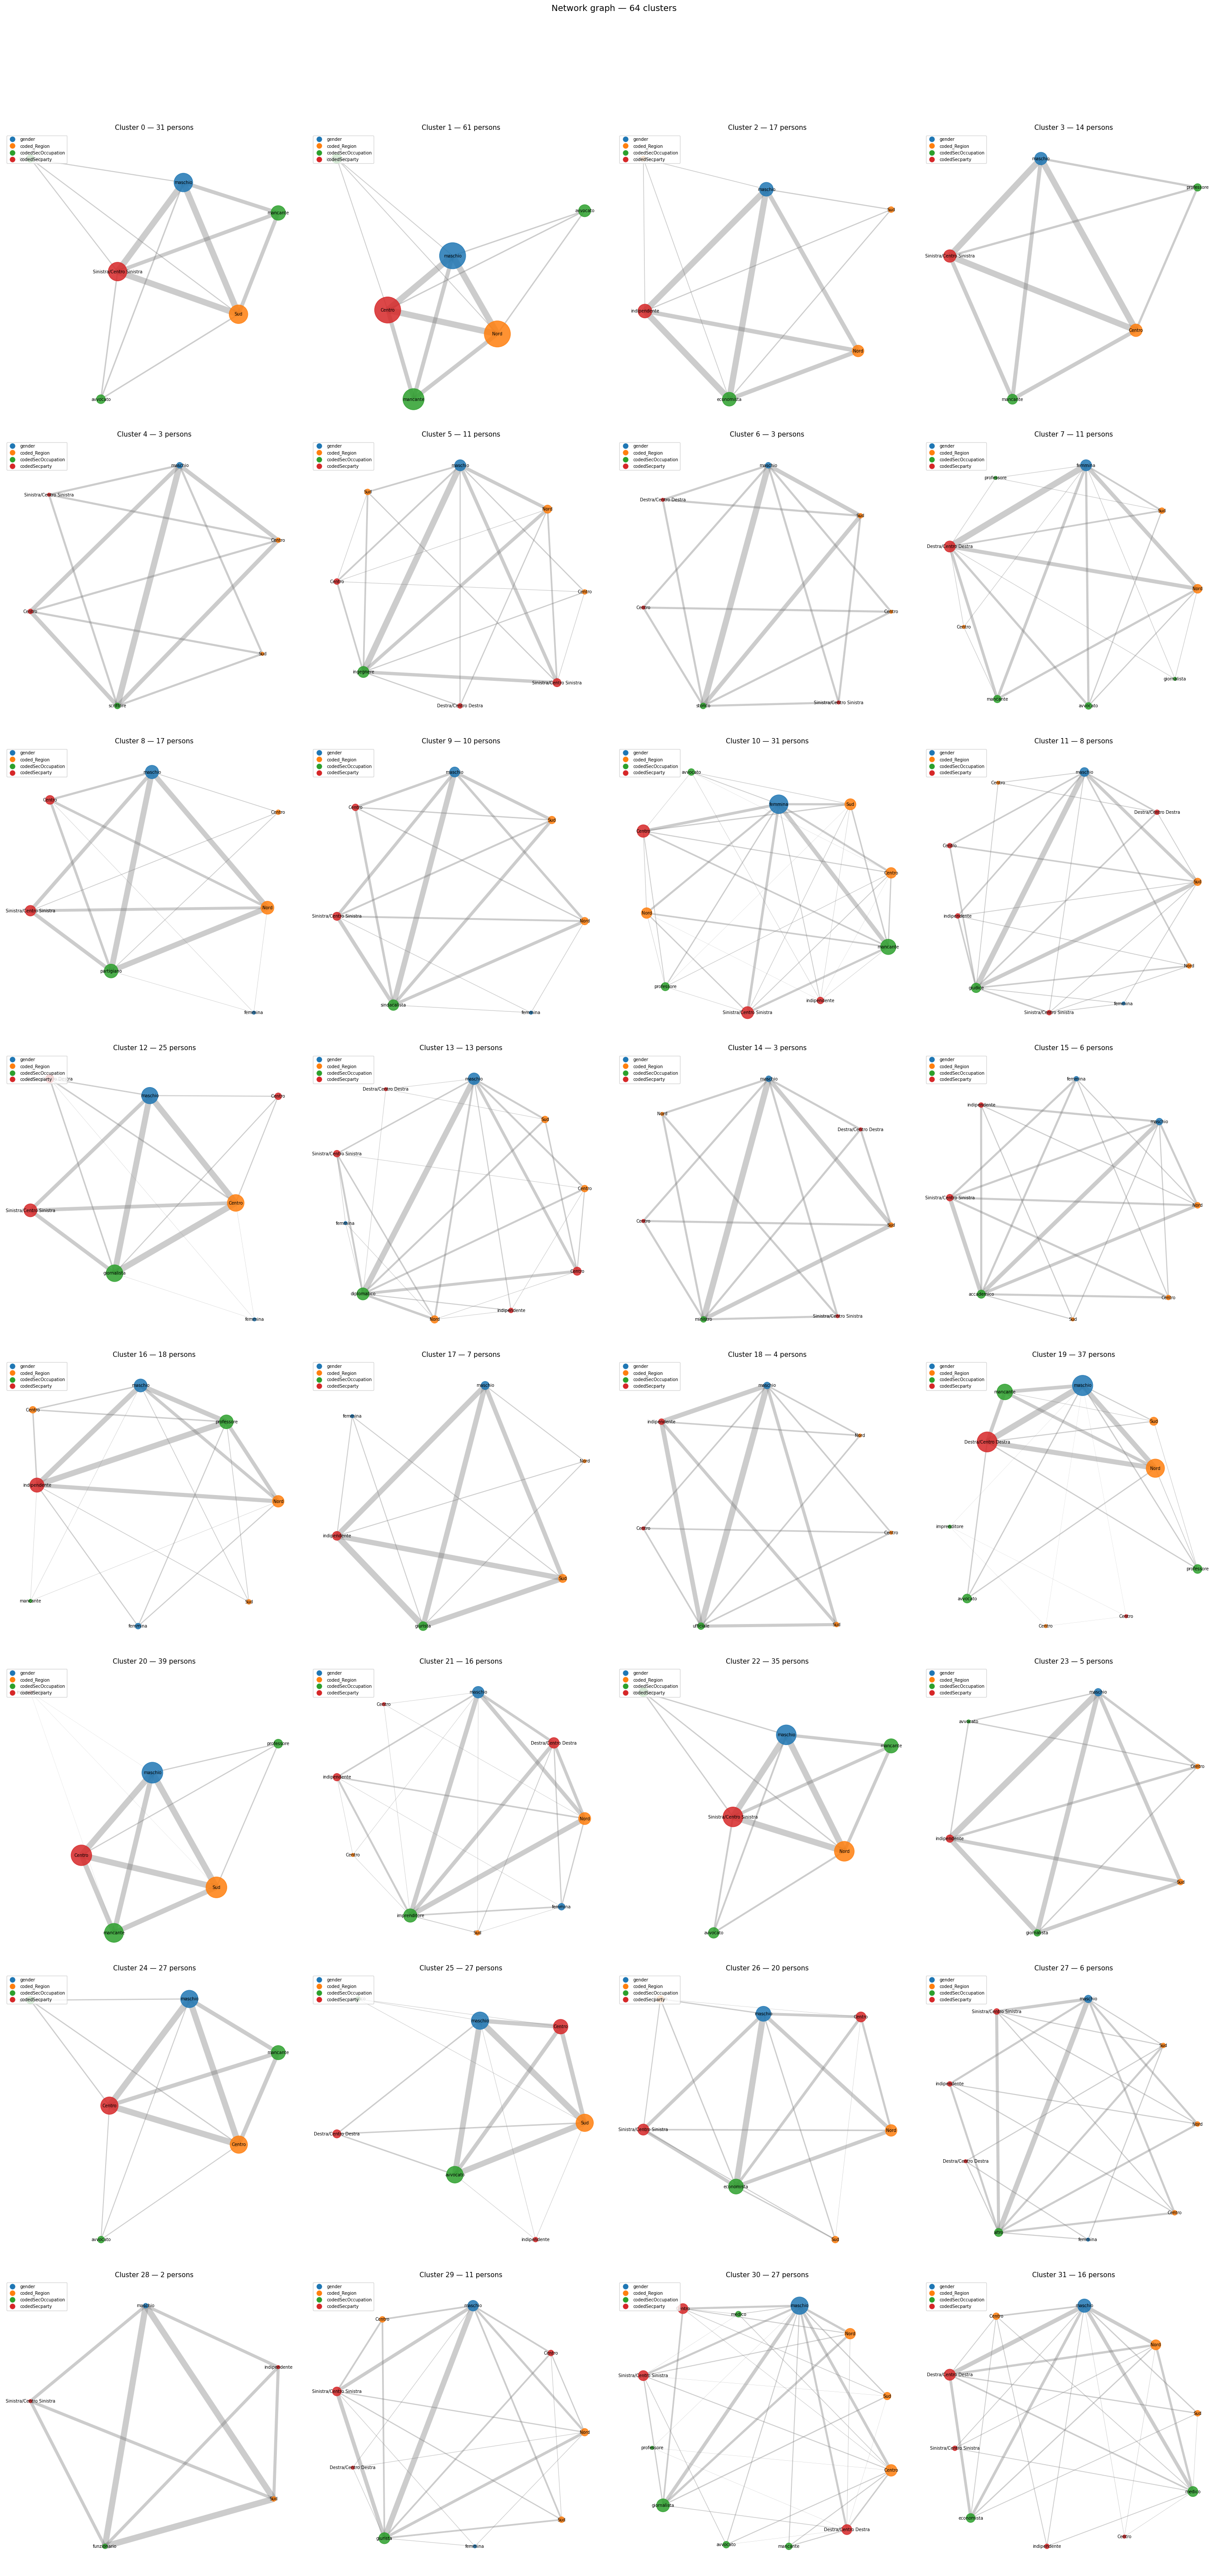

In [90]:
## ici on voit les attractions de modalités
# les variables au centre ou très liées structurent le cluster
pict_address='images/kmeans_ACM_clusters_4_variables_64cl.png'
cf.plot_cluster_networks(df_actives, categorical_cols, 64, 
        pict_address=pict_address)

## Test clusters correspondence

In [ ]:
observed

In [ ]:
from sklearn.metrics import adjusted_rand_score, confusion_matrix
from scipy.stats import chi2_contingency


y_kmodes = dfq['cluster_kmode']
y_mca = dfq['cluster_kmean']

# 1. Overall Similarity: Adjusted Rand Index (ARI)
ari = adjusted_rand_score(y_kmodes, y_mca)


In [ ]:
print(f"Adjusted Rand Index: {ari:.3f}")


In [ ]:


# Optional: Normalize rows to see probability mapping
row_norm = observed.div(observed.sum(axis=1), axis=0)
print("\nRow-Normalized Mapping (Probability of MCA cluster given k-modes cluster):")
print(row_norm.round(2))

In [ ]:
bl.check_chi_square_test_validity(observed)

In [ ]:
expected=bl.bivariate_stats(observed)

### CA

In [ ]:
afc = fa.CA(row_labels=observed.index,col_labels=observed.columns)
afc.fit(observed.values)

In [ ]:
### Inertia (Phi-square - Eigenvalue):  0.108
cal.print_eigenvalue(afc)

In [ ]:
cal.dim_contributions(afc)

In [ ]:
# Represent dimension 1 and 2
afc.mapping(num_x_axis=1,num_y_axis=2,figsize=(10,10))

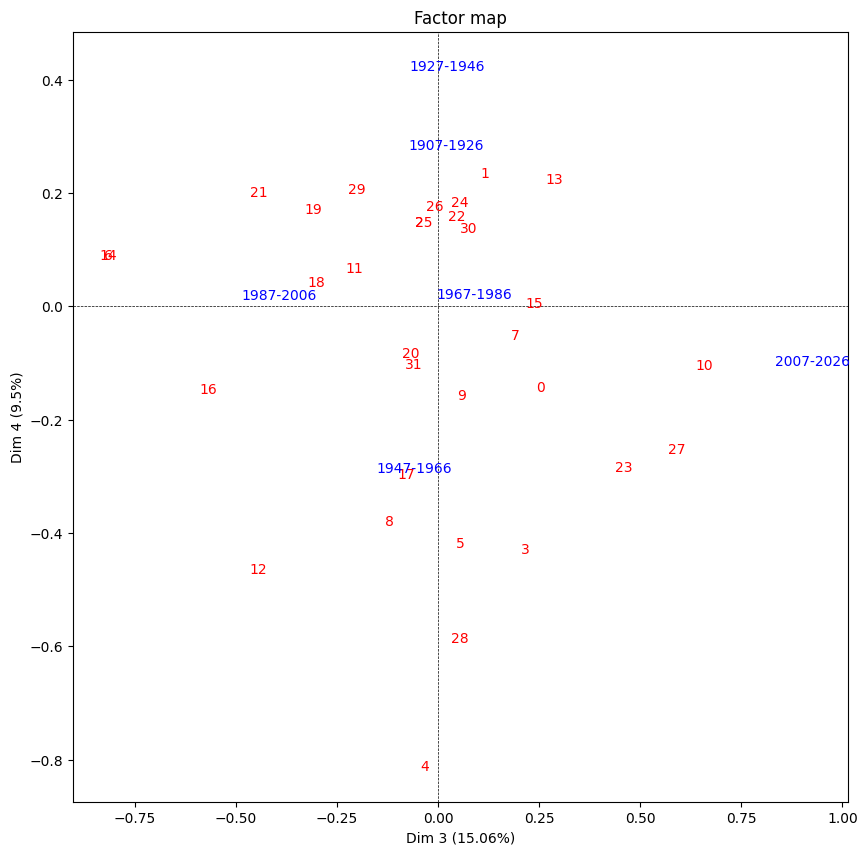

In [92]:
# Represent dimension 2 and 3
afc.mapping(num_x_axis=3,num_y_axis=4,figsize=(10,10))

In [93]:
observed.head(2)

periodsActivity,1907-1926,1927-1946,1947-1966,1967-1986,1987-2006,2007-2026
cluster,,,,,,
0,1,3,9,12,3,3
1,7,16,19,10,5,4


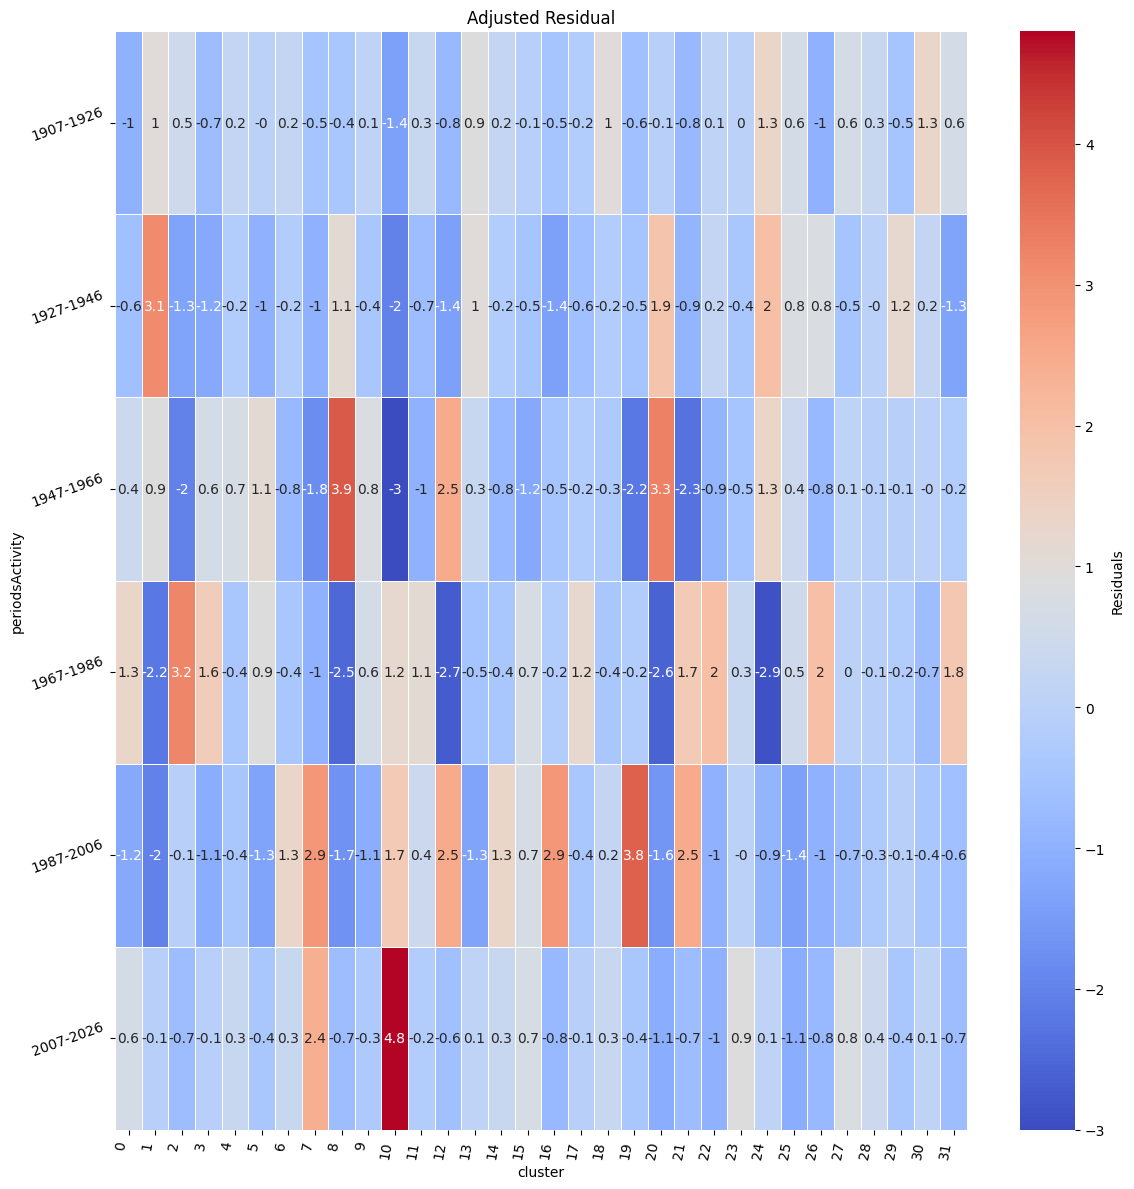

In [94]:
pp = bl.plot_chi2_residuals(observed.T, figsize=(12, 12))

In [95]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.max_colwidth', None):
    display(pd.DataFrame(clu_prof_short[['label','number_in_cl','number_centroid','number_f', 'prop_f']]))

,label,number_in_cl,number_centroid,number_f,prop_f
0,0_maschio_Sud_mancante_Sinistra/Centro Sinistra,31,19,0,0.00
1,1_maschio_Nord_mancante_Centro,61,40,0,0.00
2,2_maschio_Nord_economista_indipendente,17,12,0,0.00
3,3_maschio_Centro_mancante_Sinistra/Centro Sinistra,14,9,0,0.00
4,4_maschio_Centro_scrittore_Centro,3,1,0,0.00
5,5_maschio_Nord_ingegnere_Sinistra/Centro Sinistra,11,3,0,0.00
6,6_maschio_Sud_storico_Centro,3,0,0,0.00
7,7_femmina_Nord_mancante_Destra/Centro Destra,11,4,11,1.00
8,8_maschio_Nord_partigiano_Sinistra/Centro Sinistra,17,8,1,0.06
9,9_maschio_Nord_sindacalista_Sinistra/Centro Sinistra,10,2,1,0.10
